This notebook contains the EDA, data processing, and model building ideas for project **CO2 Emissions by Cars** which can be accessed at : [GitHub](https://github.com/d0r1h/CO2-Emission-by-Cars)

[Dataset](https://www.kaggle.com/datasets/debajyotipodder/co2-emission-by-vehicles) captures the details of how CO2 emissions by a vehicle can vary with the different features. The dataset has been taken from Canada Government official open data website.

## Table of Contents

1. **[Import Libraries](#import_lib)**
2. **[Set Options](#set_options)**
3. **[Read Data](#Read_Data)**
4. **[Exploratory Data Analysis](#data_preparation)**
    - 4.1 - [Preparing the Dataset](#Data_Preparing)
        - 4.1.1 - [Data Dimension](#Data_Shape)
        - 4.1.2 - [Data Types](#Data_Types)
        - 4.1.3 - [Missing Values](#Missing_Values)
        - 4.1.4 - [Duplicate Data](#duplicate)
    - 4.2 - [Understanding the Dataset](#Data_Understanding)
        - 4.2.1 - [Summary Statistics](#Summary_Statistics)
        - 4.2.2 - [Correlation](#correlation)
        - 4.2.3 - [Analyze Categorical Variables](#analyze_cat_var)
        - 4.2.4 - [Anaylze Target Variable](#analyze_tar_var)
        - 4.2.5 - [Analyze Relationship Between Target and Independent Variables](#analyze_tar_ind_var)
        - 4.2.6 - [Feature Engineering](#feature_eng)
5. **[Data Pre-Processing](#data_pre)**
    - 5.1 - [Outliers](#out)
        - 5.1.1 - [Discovery of Outliers](#dis_out)
        - 5.1.2 - [Removal of Outliers](#rem_out)
        - 5.1.3 - [Rechecking of Correlation](#rec_cor)
    - 5.2 - [Categorical Encoding](#cat_enc)
6. **[Building Multiple Linear Regression Models](#bui_mlr_mod)**
    - 6.1 - [Multiple Linear Regression - Basic Model](#bas_mod)
    - 6.2 - [Feature Transformation](#fea_tra)
    - 6.3 - [Feature Scaling](#fea_sca)
    - 6.4 - [Multiple Linear Regression - Full Model - After Feature Scaling](#mod_aft_sca)
    - 6.5 - [Assumptions Before Multiple Linear Regression Model](#ass_bef)
        - 6.5.1 - [Assumption #1: If Target Variable is Numeric](#tgt_num)
        - 6.5.2 - [Assumption #2: Presence of Multi-Collinearity](#pre_mul_col)
    - 6.6 - [Multiple Linear Regression - Full Model - After PCA](#mod_pca)
    - 6.7 - [Feature Selection](#fea_sel)
        - 6.7.1 - [Forward Selection](#for_sel)
        - 6.7.2 - [Backward Elimination](#bac_eli)
    - 6.8 - [Multiple Linear Regression - Full Model - After Feature Selection](#mod_fea_sel)
    - 6.9 - [Assumptions After Multiple Linear Regression Model](#ass_aft)
        - 6.9.1 - [Assumption #1: Linear Relationship Between Dependent and Independent Variable](#lr_dep_ind)
        - 6.9.2 - [Assumption #2: Checking for Autocorrelation](#che_aut_cor)
        - 6.9.3 - [Assumption #3: Checking for Heterskedacity](#che_het)
        - 6.9.4 - [Assumption #4: Test for Normality](#tes_nor)
            - 6.9.4.1 - [Q-Q Plot](#qq_plt)
            - 6.9.4.2 - [Shapiro Wilk Test](#sha_wil_tes)
7. **[Model Evaluation](#mod_eva)**
    - 7.1 - [Measures of Variation](#mea_var)
    - 7.2 - [Inferences about Intercept and Slope](#inf_int_slo)
    - 7.3 - [Confidence Interval for Intercept and Slope](#con_int_slo)
    - 7.4 - [Compare Regression Results](#com_reg_res)
8. **[Model Performance](#mod_per)**
    - 8.1 - [Mean Square Error(MSE)](#mse)
    - 8.2 - [Root Mean Squared Error(RMSE)](#rmse)
    - 8.3 - [Mean Absolute Error(MAE)](#mae)
    - 8.4 - [Mean Absolute Percentage Error(MAPE)](#mape)
    - 8.5 - [Resultant Table](#res_tab)
9. **[Model Optimization](#mod_opt)**
    - 9.1 - [Bias](#bias)
    - 9.2 - [Variance](#var)
    - 9.3 - [Model Validation](#mod_val)
      - 9.3.1 - [Cross Validation](#cro_val)
      - 9.3.2 - [Leave One Out Cross Validation(LOOCV)](#loocv)
    - 9.4 - [Gradient Descent](#gra_des)
    - 9.5 - [Regularization](#reg)
      - 9.5.1 - [Ridge Regression Model](#ridge)
      - 9.5.2 - [Lasso Regression Model](#lasso)
      - 9.5.3 - [Elastic Net Regression Model](#ela_net)
      - 9.5.4 - [Grid Search CV](#gri_sea)
10. **[Displaying Score Summary](#dis_sco_sum)**
11. **[Conclusion](#conclu)**

#### **Data Description**


**Model**

1. 4WD/4X4 = Four-wheel drive
2. AWD = All-wheel drive
3. FFV = Flexible-fuel vehicle
4. SWB = Short wheelbase
5. LWB = Long wheelbase
6. EWB = Extended wheelbase

**Transmission**

1. A = Automatic
2. AM = Automated manual
3. AS = Automatic with select shift
4. AV = Continuously variable
5. M = Manual
6. 3 - 10 = Number of gears

**Fuel type**

1. X = Regular gasoline
2. Z = Premium gasoline
3. D = Diesel
4. E = Ethanol (E85)
5. N = Natural gas

**Fuel Consumption**

City and highway fuel consumption ratings are shown in litres per 100 kilometres (L/100 km) - the combined rating (55% city, 45% hwy) is shown in L/100 km and in miles per gallon (mpg).

**CO2 Emissions**

The tailpipe emissions of carbon dioxide (in grams per kilometre) for combined city and highway driving

# 1. Import Libraries <a id='import_lib'></a>

In [1]:
!pip install mlxtend -qq

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels
from scipy import stats
import statsmodels.api as sm
from scipy.stats import shapiro
import statsmodels.stats.api as sms
from statsmodels.compat import lzip
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.tools.eval_measures import rmse
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_selection import RFE
from mlxtend.feature_selection import SequentialFeatureSelector as sfs
from sklearn.linear_model import Lasso, Ridge, ElasticNet, SGDRegressor, LinearRegression
from sklearn.model_selection import KFold, LeaveOneOut, GridSearchCV, cross_val_score, train_test_split

%matplotlib inline

from warnings import filterwarnings
filterwarnings('ignore')

# 2. Set Options <a id='set_options'></a>

In [3]:
from google.colab import files
uploaded = files.upload()


Saving CO2 Emissions_Canada.csv to CO2 Emissions_Canada.csv


In [4]:
pd.options.display.max_columns = None
pd.options.display.max_rows = None
pd.options.display.float_format = '{:.6f}'.format

# 3. Read Data <a id='Read_Data'></a>

In [6]:
data = pd.read_csv("CO2 Emissions_Canada.csv")

data.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.000000,4,AS5,Z,9.900000,6.700000,8.500000,33,196
1,ACURA,ILX,COMPACT,2.400000,4,M6,Z,11.200000,7.700000,9.600000,29,221
2,ACURA,ILX HYBRID,COMPACT,1.500000,4,AV7,Z,6.000000,5.800000,5.900000,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.500000,6,AS6,Z,12.700000,9.100000,11.100000,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.500000,6,AS6,Z,12.100000,8.700000,10.600000,27,244


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: flo

# 4. Exploratory Data Analysis <a id='data_preparation'></a>

## 4.1 Preparing the Dataset <a id='Data_Preparing'></a>

**Renaming Columns**

In [8]:
data = data.rename(columns={
    'Vehicle Class': 'Vehicle_Class',
    'Engine Size(L)': 'Engine_Size',
    'Fuel Type': 'Fuel_Type',
    'Fuel Consumption City (L/100 km)': 'Fuel_Consumption_City',
    'Fuel Consumption Hwy (L/100 km)': 'Fuel_Consumption_Hwy',
    'Fuel Consumption Comb (L/100 km)': 'Fuel_Consumption_Comb',
    'Fuel Consumption Comb (mpg)': 'Fuel_Consumption_Comb1',
    'CO2 Emissions(g/km)': 'CO2_Emissions'
})

### 4.1.1 Data Dimensions <a id='Data_Shape'></a>

In [9]:
data.shape

(7385, 12)

In this dataset we have 7384 records across 12 features

### 4.1.2 Data Types <a id='Data_Types'></a>

In [10]:
data.dtypes

,0
Make,object
Model,object
Vehicle_Class,object
Engine_Size,float64
Cylinders,int64
Transmission,object
Fuel_Type,object
Fuel_Consumption_City,float64
Fuel_Consumption_Hwy,float64
Fuel_Consumption_Comb,float64


The dataset contains **5 object columns, 3 int column and 4 float columns**

### 4.1.3 Missing Values <a id='Missing_Values'></a>

In [11]:
missing_value = pd.DataFrame({
    'Missing Value': data.isnull().sum(),
    'Percentage': (data.isnull().sum() / len(data))*100
})

In [12]:
missing_value.sort_values(by='Percentage', ascending=False)

,Missing Value,Percentage
Make,0,0.000000
Model,0,0.000000
Vehicle_Class,0,0.000000
Engine_Size,0,0.000000
Cylinders,0,0.000000
Transmission,0,0.000000
Fuel_Type,0,0.000000
Fuel_Consumption_City,0,0.000000
Fuel_Consumption_Hwy,0,0.000000
Fuel_Consumption_Comb,0,0.000000


There are **no missing values** present in this dataset

### 4.1.4 Duplicate Data <a id='duplicate'></a>

In [13]:
duplicate = data.duplicated().sum()
print('There are {} duplicated rows in the data'.format(duplicate))

There are 1103 duplicated rows in the data


In [14]:
data.drop_duplicates(inplace=True)

In [15]:
data.reset_index(inplace=True, drop=True)

Now, the dataset has **6281 records and 12 features with no missing and duplicate values**

## 4.2  Data Understanding <a id='Data_Understanding'></a>

### 4.2.1 Summary Statistics <a id='Summary_Statistics'></a>

In [16]:
data.describe(include=np.number)

,Engine_Size,Cylinders,Fuel_Consumption_City,Fuel_Consumption_Hwy,Fuel_Consumption_Comb,Fuel_Consumption_Comb1,CO2_Emissions
count,6282.000000,6282.000000,6282.000000,6282.000000,6282.000000,6282.000000,6282.000000
mean,3.161812,5.618911,12.610220,9.070583,11.017876,27.411016,251.157752
std,1.365201,1.846250,3.553066,2.278884,2.946876,7.245318,59.290426
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,208.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.700000,10.300000,12.700000,32.000000,289.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


1. The average amount of CO2 emitted from cars is 251 g/km
2. Atleast 4 Litres of fuel is consumed be it the car is on city roads or highway
3. About 75% of the cars have 6 or less cylinders
4. The amount of fuel consumed by cars on city roads is comparitvely greater than that of highway

In [17]:
data.describe(include = object)

,Make,Model,Vehicle_Class,Transmission,Fuel_Type
count,6282,6282,6282,6282,6282
unique,42,2053,16,27,5
top,FORD,F-150 FFV,SUV - SMALL,AS6,X
freq,577,32,1006,1139,3039


1. There are a total of 42 different car companies with 2053 different car models
2. Vehicles are divided into 16 different classes with SUV-Small vehicles frequenting the most
3. 4 different types of fuels used by cars have been identified and fuel X seems to be the most famous
4. Most of the cars have AS6 transmission

### 4.2.2 Correlation <a id='correlation'></a>

In [18]:
data_num_features = data.select_dtypes(include=np.number)

print('The numerical columns in the dataset are: ',data_num_features.columns)

The numerical columns in the dataset are:  Index(['Engine_Size', 'Cylinders', 'Fuel_Consumption_City',
       'Fuel_Consumption_Hwy', 'Fuel_Consumption_Comb',
       'Fuel_Consumption_Comb1', 'CO2_Emissions'],
      dtype='object')


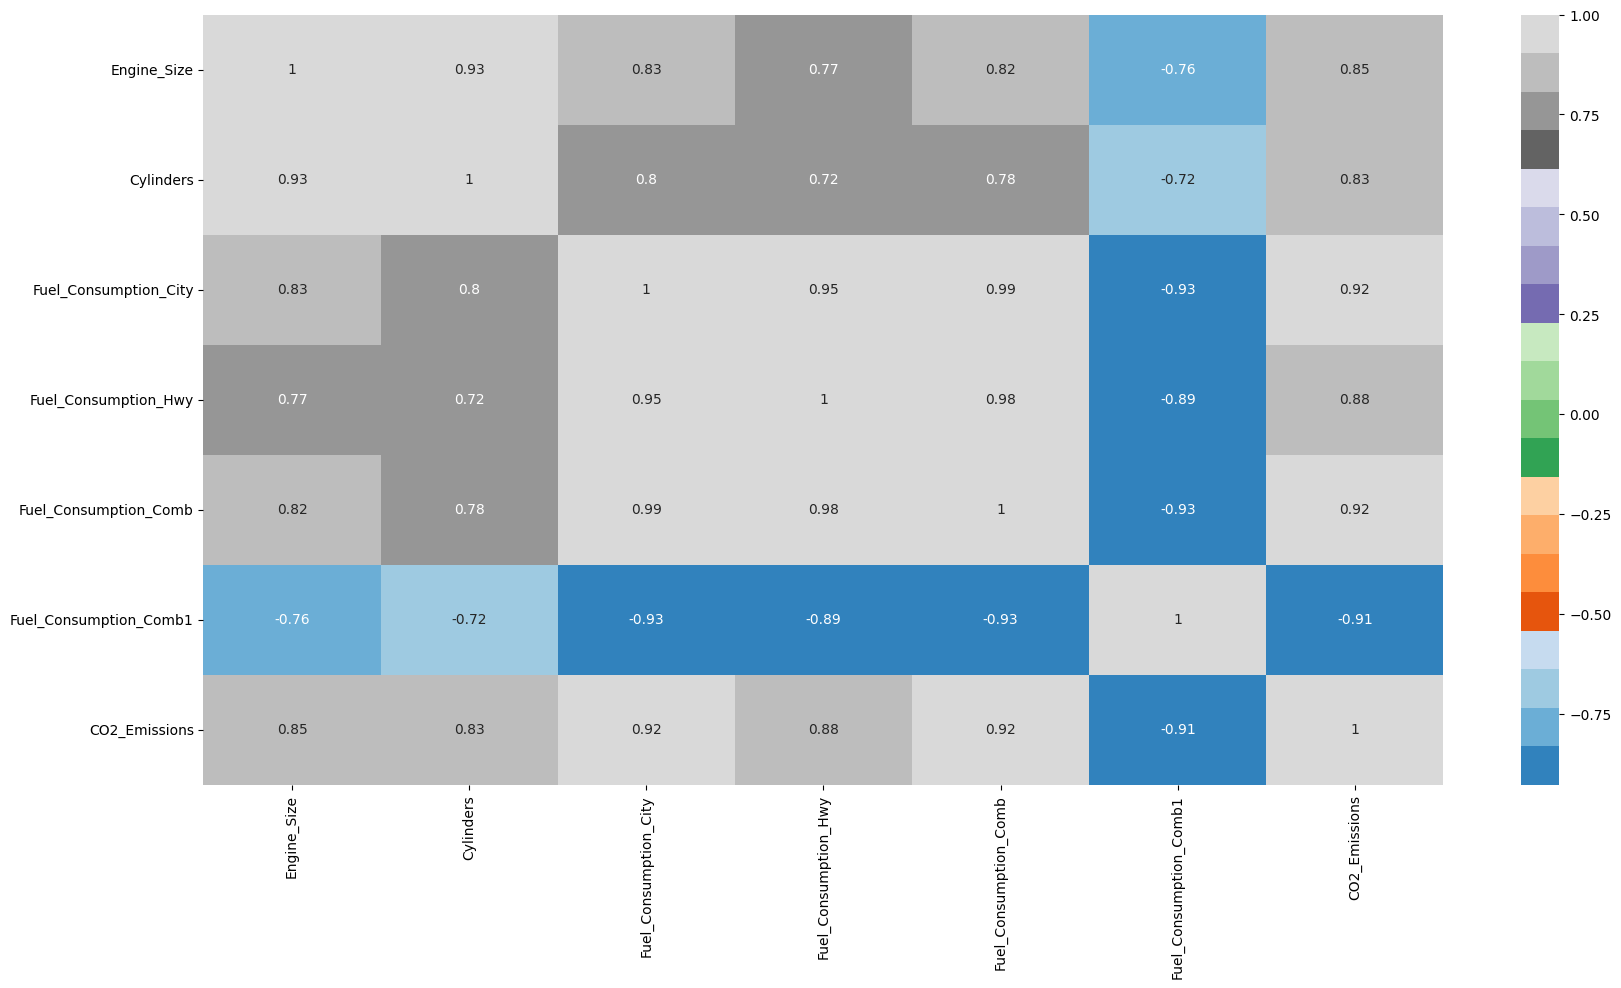

In [19]:
plt.figure(figsize=(20,10))

corr =  data_num_features.corr()

corr =data_num_features.corr(method='pearson')
sns.heatmap(corr, annot=True,cmap='tab20c')
plt.show()

1. Fuel_Consumption_Comb1 has a high negative correaltion(<-0.9) with CO2_Emissions, Fuel_Consumption_Comb and Fuel_Consumption_City
2. CO2_Emissions has high positive correlation(>0.9) with Fuel_Consumption_Comb and Fuel_Consumption_City

### 4.2.3 Analyse Categorical Variables <a id='analyze_cat_var'></a>

In [23]:
data_cat_features = data.select_dtypes(include='object')
data_cat_features1 = data_cat_features[['Vehicle_Class', 'Transmission', 'Fuel_Type', 'Model','Make']]

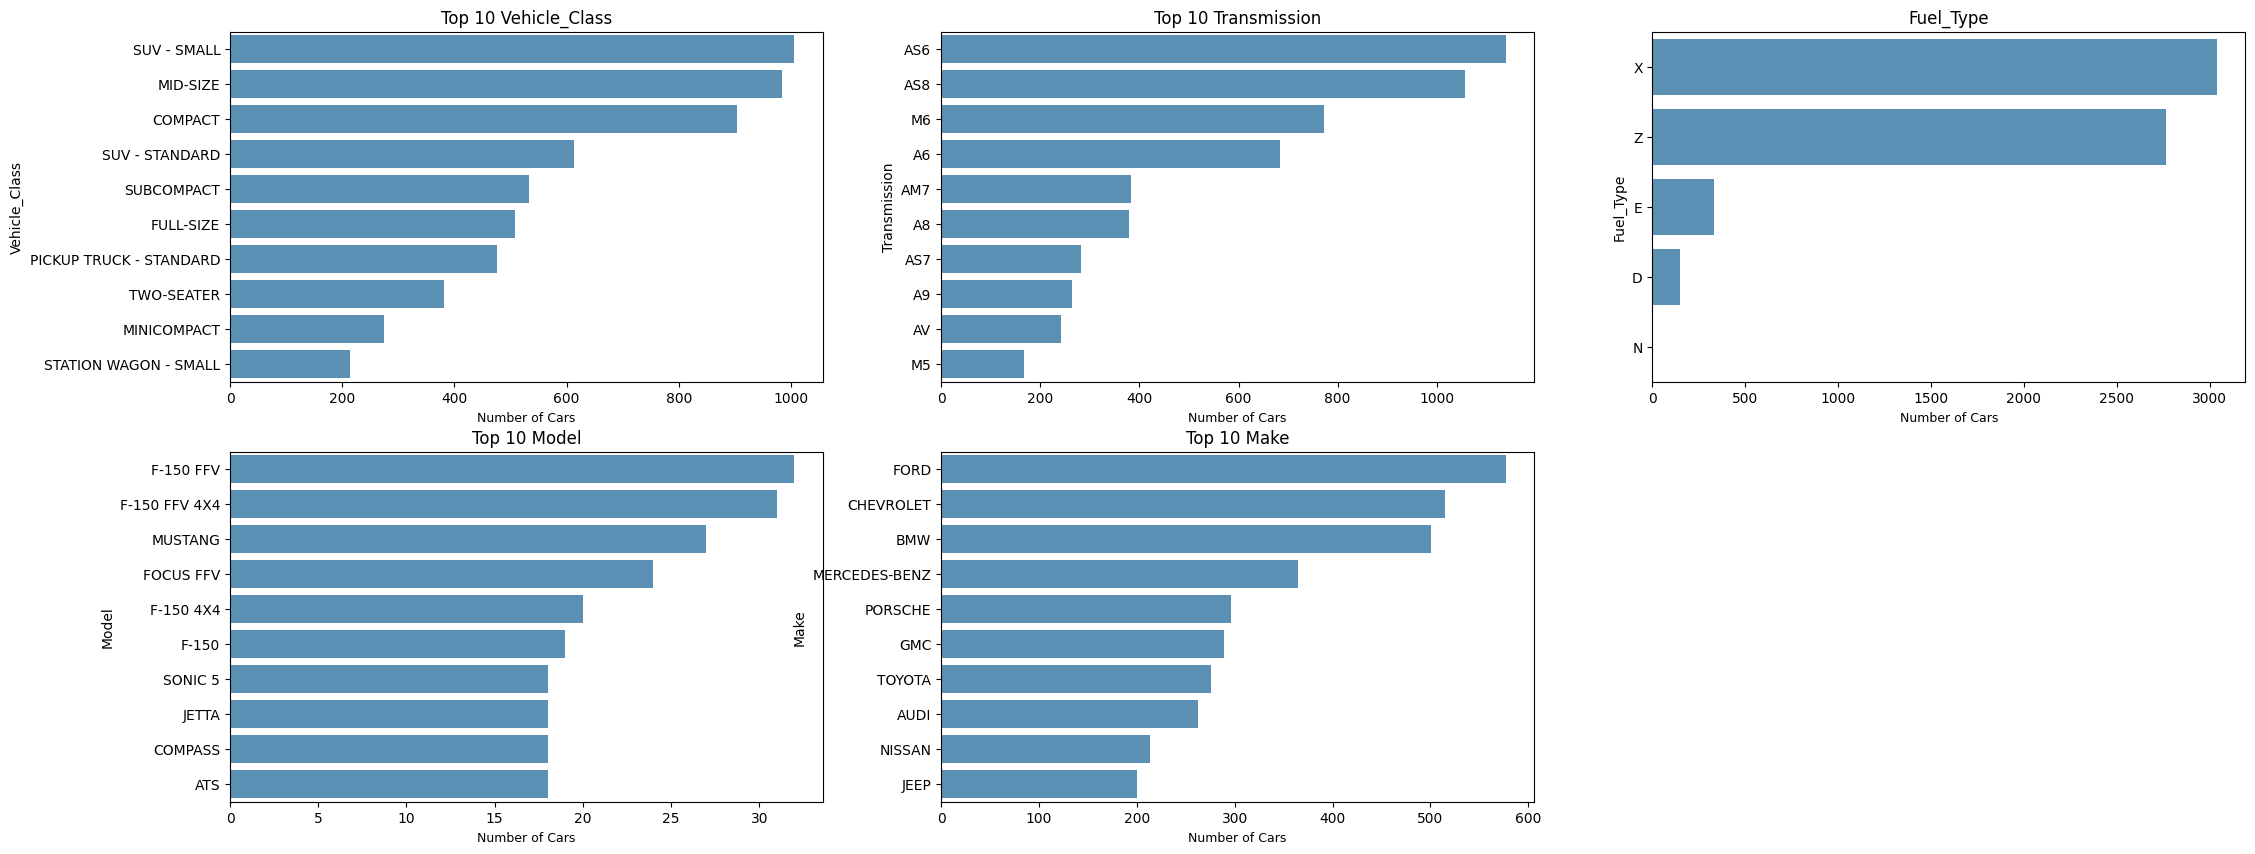

In [24]:
fig,ax= plt.subplots(nrows=2,ncols=3,figsize=(26, 10))

for variable, subplot in zip(data_cat_features1.columns,ax.flatten()):
    cat_count  = data[variable].value_counts()
    cat_count10 = cat_count[:10,]
    z = sns.barplot(x=cat_count10.values, y=cat_count10.index, alpha=0.8, ax=subplot)
    if cat_count.size > 10:
        z.set_title('Top 10 {}'.format(variable))
    else:
        z.set_title(variable)
    z.set_xlabel('Number of Cars', fontsize=9)

fig.delaxes(ax[1][2])

1. Top 10 Make: Most of the cars on Canadian roads are made by Ford
2. Top 10 Model: The F-150 FFV is amongst the most famous models driven in Canada
3. Top 10 Vehicle_Class: SUV-Small is the preferred class of vehicle amongst the Canadians
4. Top 10 Transmission: More than 1000 cars have AS6 and AS8 transmission types
5. Fuel Type: Majority of the cars in Canada use Fuel type X and Z

### 4.2.4 Analyse Target Variable <a id='analyze_tar_var'></a>

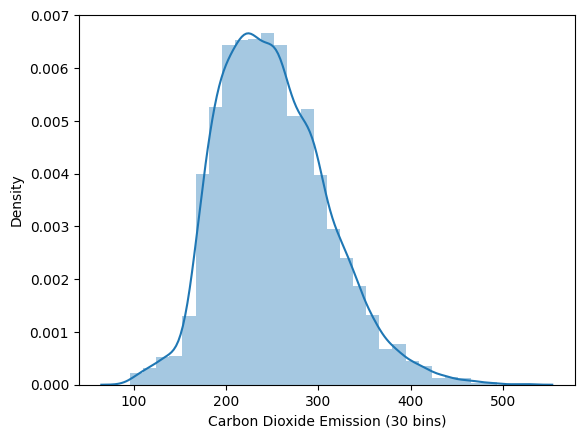

In [25]:
sns.distplot(data['CO2_Emissions'], bins=30, kde=True, axlabel='Carbon Dioxide Emission (30 bins)')
plt.show()

From the above histogram, we can see that CO2_Emissions is moderately positive skewed

In [26]:
mean = data['CO2_Emissions'].mean()
mode = data['CO2_Emissions'].mode()
median = data['CO2_Emissions'].median()

print(f'Mean for CO2 Emission is {mean}')
print(f'Median for CO2 Emission is {median}')
print(f'Mode for CO2 Emission is {mode}')

Mean for CO2 Emission is 251.1577523081821
Median for CO2 Emission is 246.0
Mode for CO2 Emission is 0    221
1    246
Name: CO2_Emissions, dtype: int64


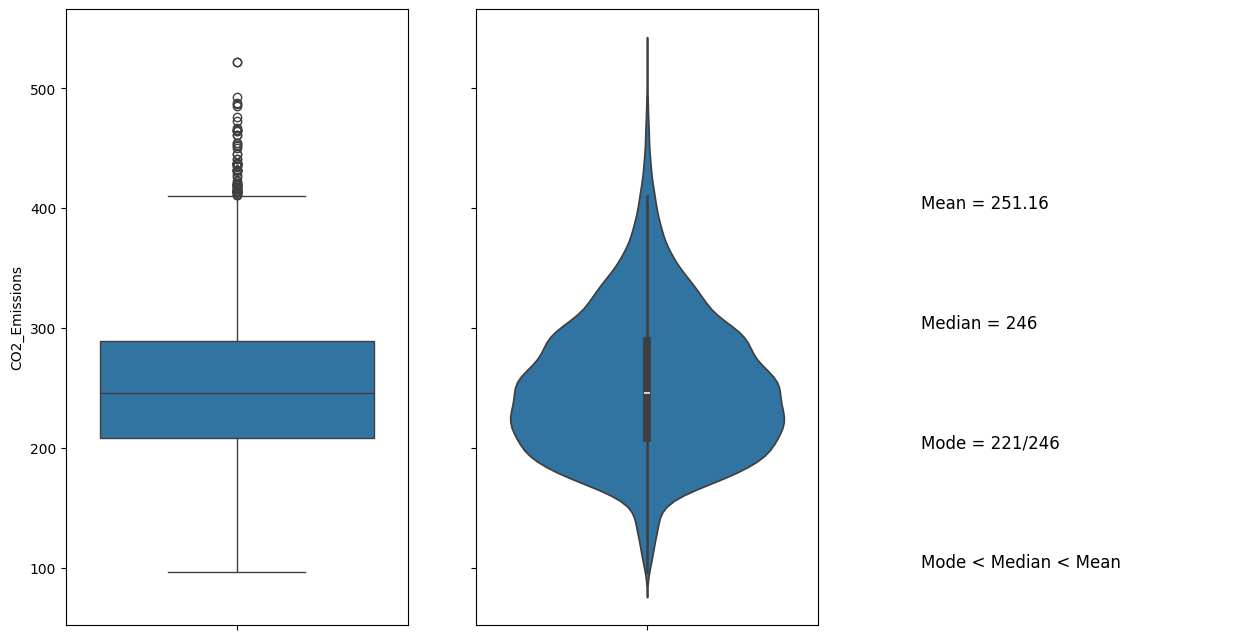

In [27]:
fig, axes = plt.subplots(1,3, sharey=True, figsize=(15,8))
sns.boxplot(y=data['CO2_Emissions'], orient="v", ax = axes[0])
sns.violinplot(y=data['CO2_Emissions'], orient="v", ax = axes[1]);
plt.text(0.1, 200, "Mode = 221/246", fontsize=12)
plt.text(0.1, 300, "Median = 246", fontsize=12)
plt.text(0.1, 400, "Mean = 251.16", fontsize=12)
plt.text(0.1, 100, "Mode < Median < Mean", fontsize=12)
plt.axis("off")
plt.show()

Of all the three statistics, the mean is the largest, while the mode is the smallest thus CO2_Emissions is positively skewed which implies that most of the CO2 Emissions are less than the average CO2 Emissions.

### 4.2.5 Analyse Relationship between Target and Independent Variables <a id='analyze_tar_ind_var'></a>

In [32]:
make_co2 = data.groupby('Make')['CO2_Emissions'].mean().sort_values(ascending=False).head(10)
model_co2 = data.groupby('Model')['CO2_Emissions'].mean().sort_values(ascending=False).head(10)
vehicle_class_co2 = data.groupby('Vehicle_Class')['CO2_Emissions'].mean().sort_values(ascending=False).head(10)
transmission_co2 = data.groupby('Transmission')['CO2_Emissions'].mean().sort_values(ascending=False).head(10)
fuel_type_co2 = data.groupby('Fuel_Type')['CO2_Emissions'].mean().sort_values(ascending=False).head()

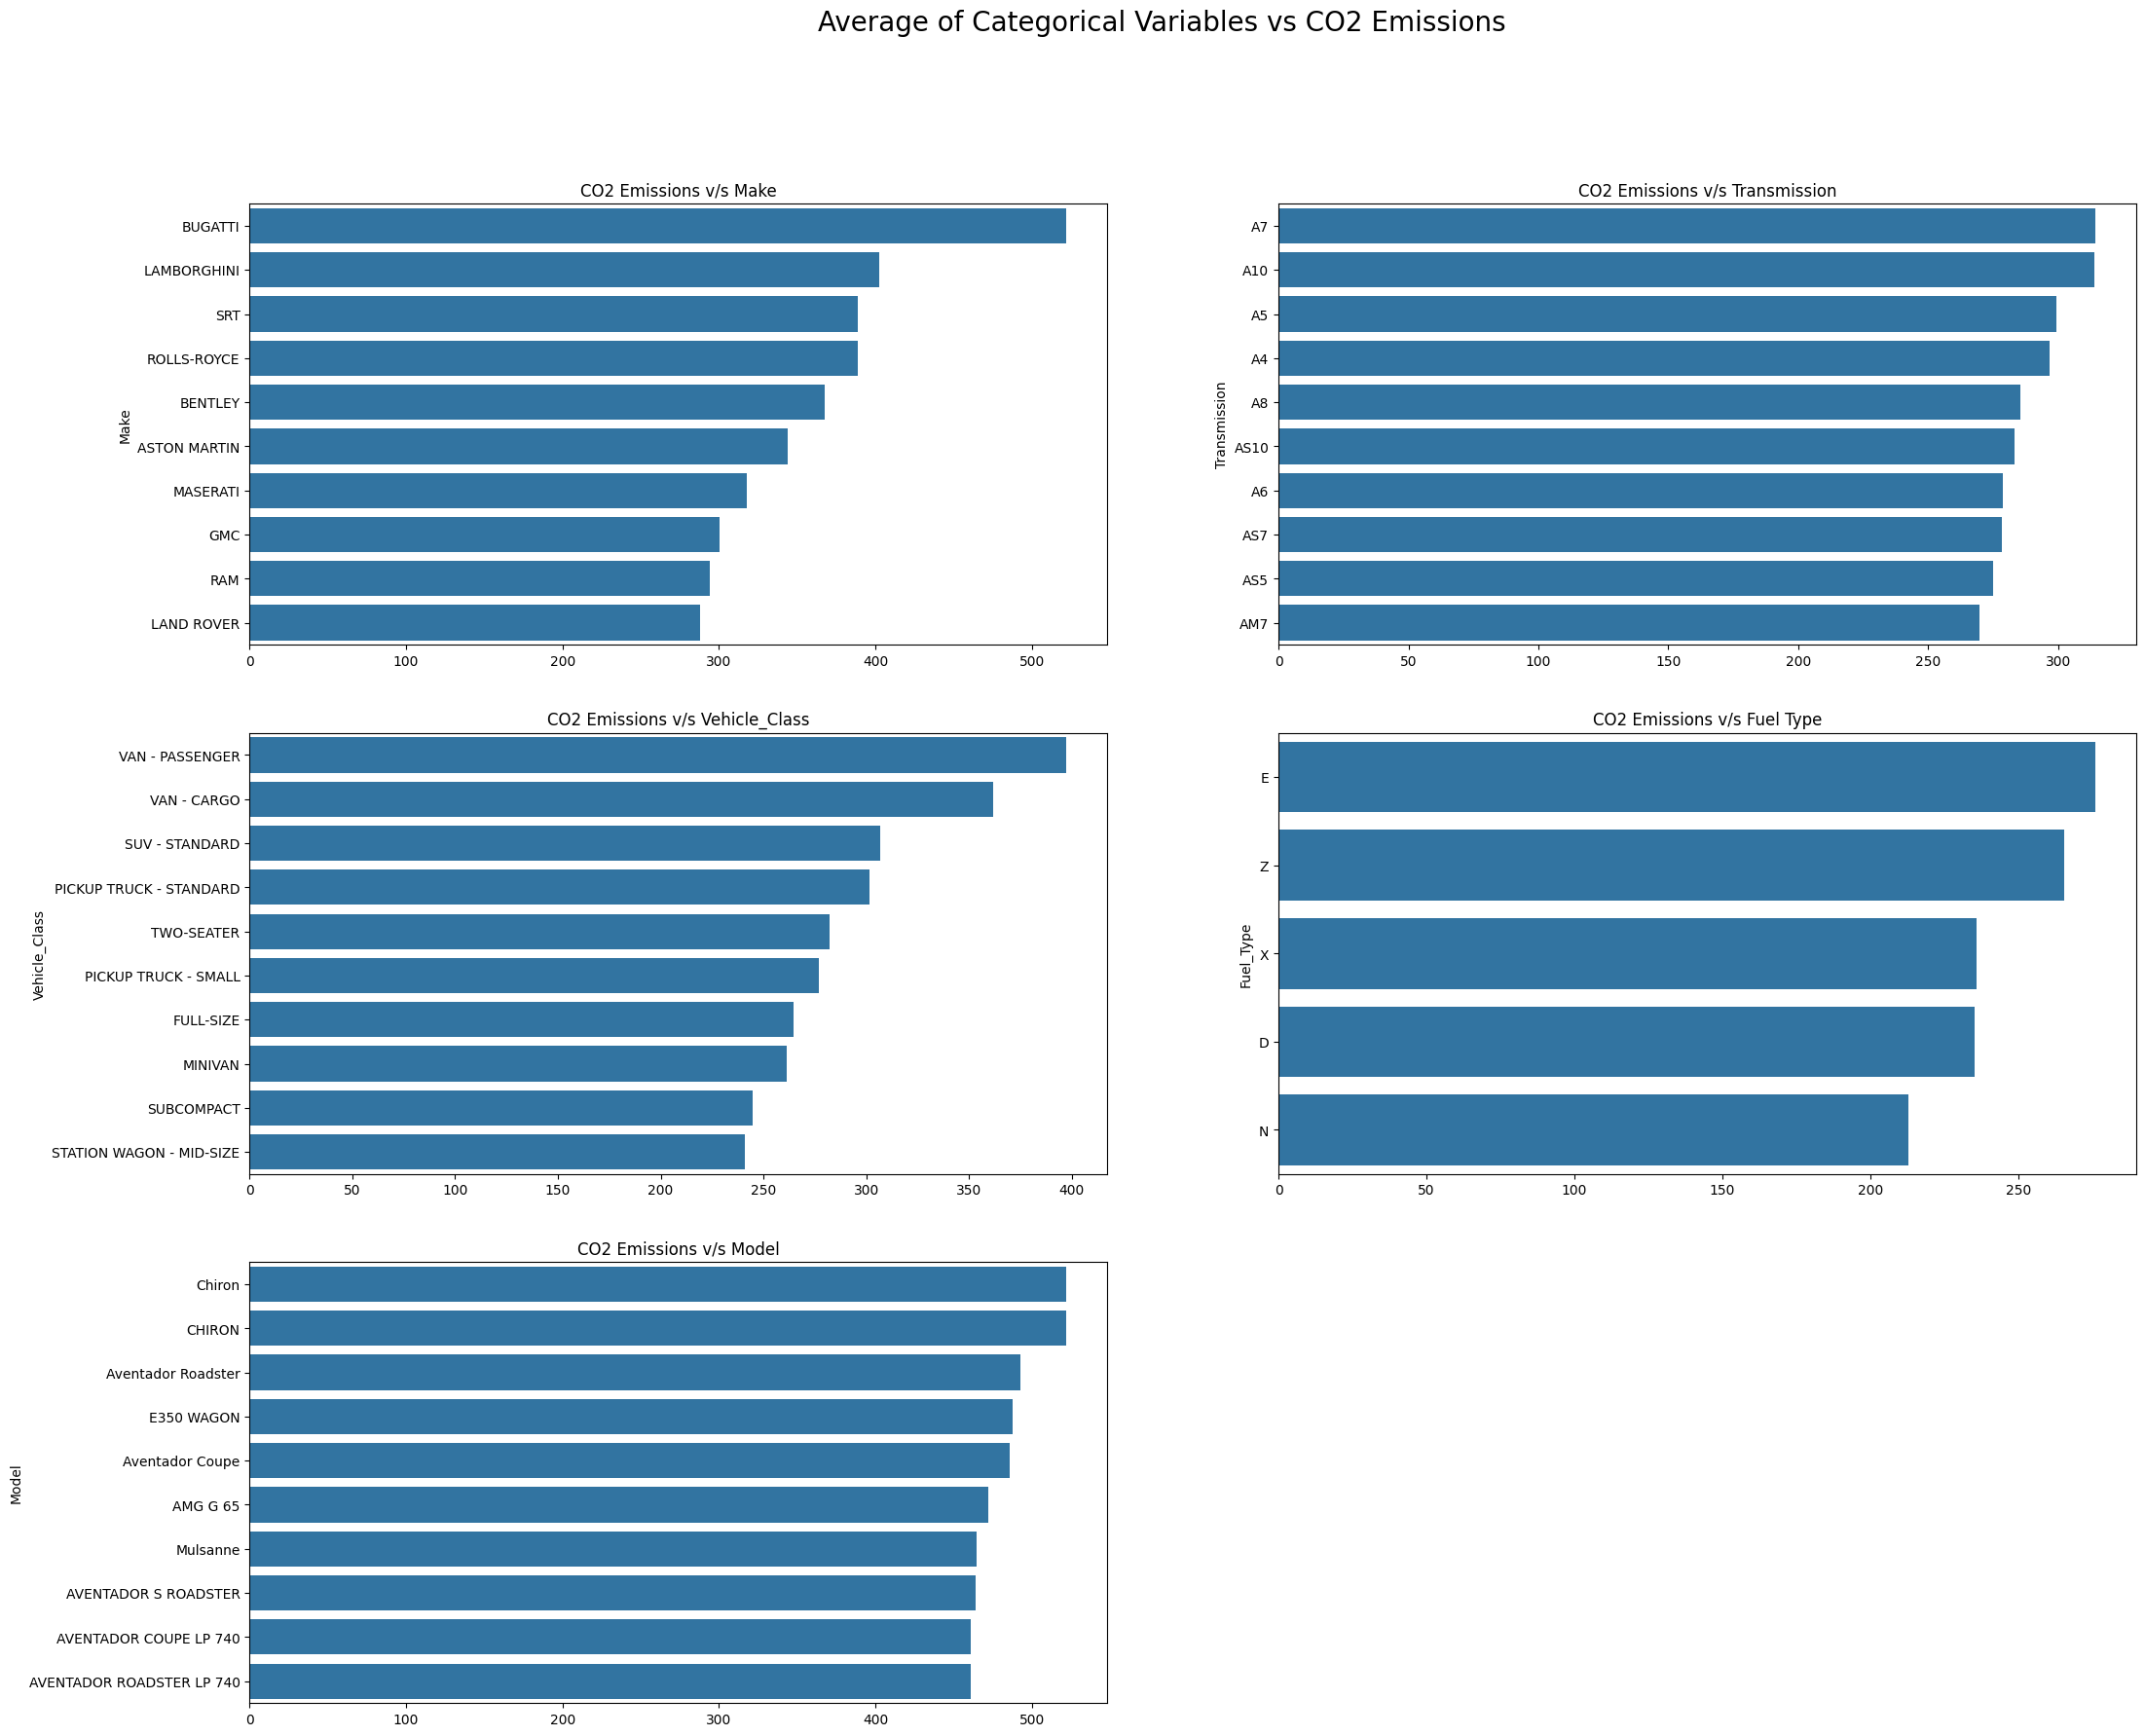

In [33]:
fig, axes = plt.subplots(3,2, figsize=(25,20))
fig.suptitle('Average of Categorical Variables vs CO2 Emissions', size=20)

sns.barplot(ax=axes[0][0],x = make_co2.values,y = make_co2.index)
axes[0][0].set_title('CO2 Emissions v/s Make')

sns.barplot(ax=axes[0][1],x = transmission_co2.values,y = transmission_co2.index)
axes[0][1].set_title('CO2 Emissions v/s Transmission')

sns.barplot(ax=axes[1][0],x = vehicle_class_co2.values,y = vehicle_class_co2.index)
axes[1][0].set_title('CO2 Emissions v/s Vehicle_Class')

sns.barplot(ax=axes[1][1], x=fuel_type_co2.values,y=fuel_type_co2.index)
axes[1][1].set_title('CO2 Emissions v/s Fuel Type')

sns.barplot(ax=axes[2][0],x = model_co2.values,y = model_co2.index)
axes[2][0].set_title('CO2 Emissions v/s Model')


fig.delaxes(axes[2][1])
plt.show()

1. CO2 Emissions v/s Make: While Ford cars are mainly found on the roads of Canada , its Bugatti that emit the most CO2 per car
2. CO2 Emissions v/s Model: Bugatti Chiron is amongst the most CO2 emitting car model
3. CO2 Emissions v/s Vehicle_Class: Most of the heavy vehicles like Vans , SUV and Pick-up truck are amongst the top few emitters of CO2
4. CO2 Emissions v/s Transmission: Most of the cars with automatic transmission emit CO2
5. CO2 Emissions v/s Fuel_Type: Cars using Fuel Type E are emitting the most CO2

**Relationship between Cylinders and CO2 Emissions**

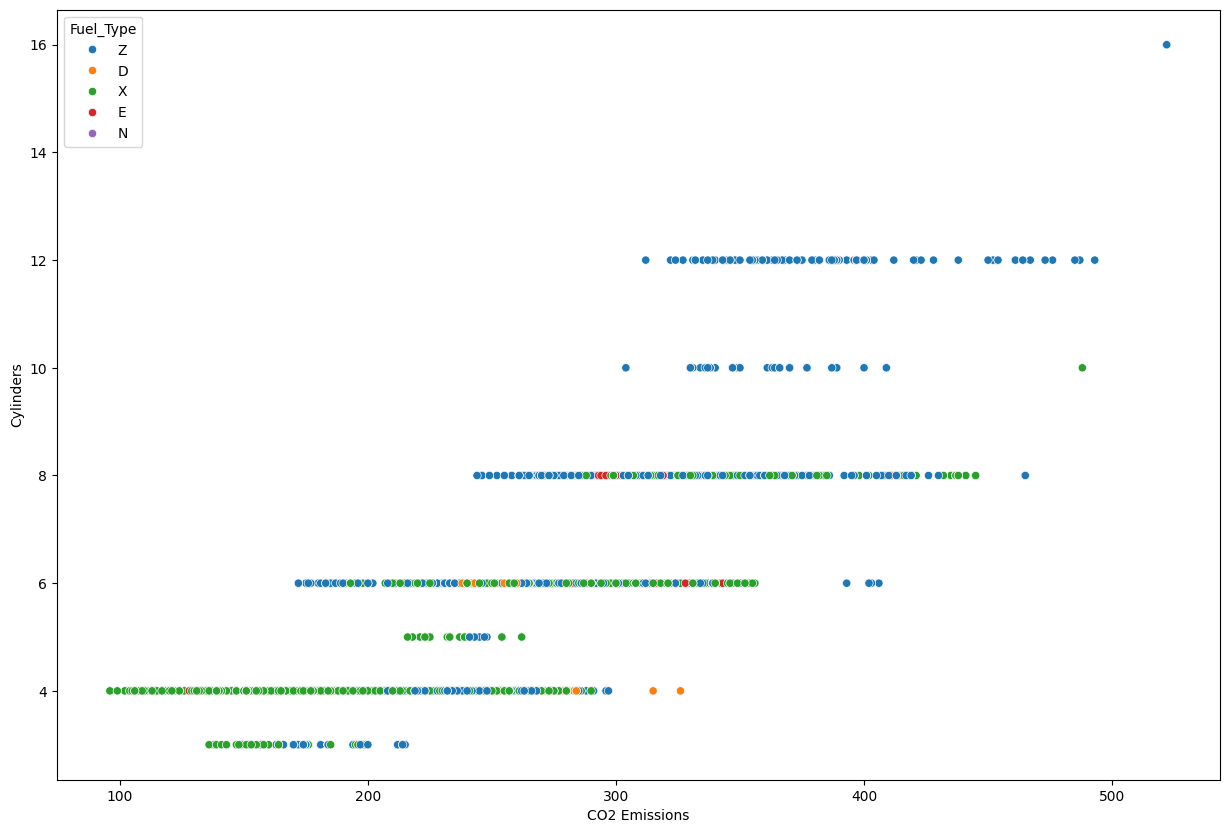

In [34]:
plt.rcParams["figure.figsize"] = (15,10)
sns.scatterplot(x='CO2_Emissions', y='Cylinders',data = data,hue='Fuel_Type')
plt.xlabel("CO2 Emissions", fontsize=10)
plt.ylabel("Cylinders", fontsize=10)
plt.show()

From the above scatter plot we can see that:
1. As the number of cylinders increase, the CO2 emissions increase
2. Cars with 8 and less than 8 cylinders prefer using Fuel Type X which result in less emissions of CO2
3. Fuel Type Z results in more CO2 emissions than the other

<Figure size 1000x500 with 0 Axes>

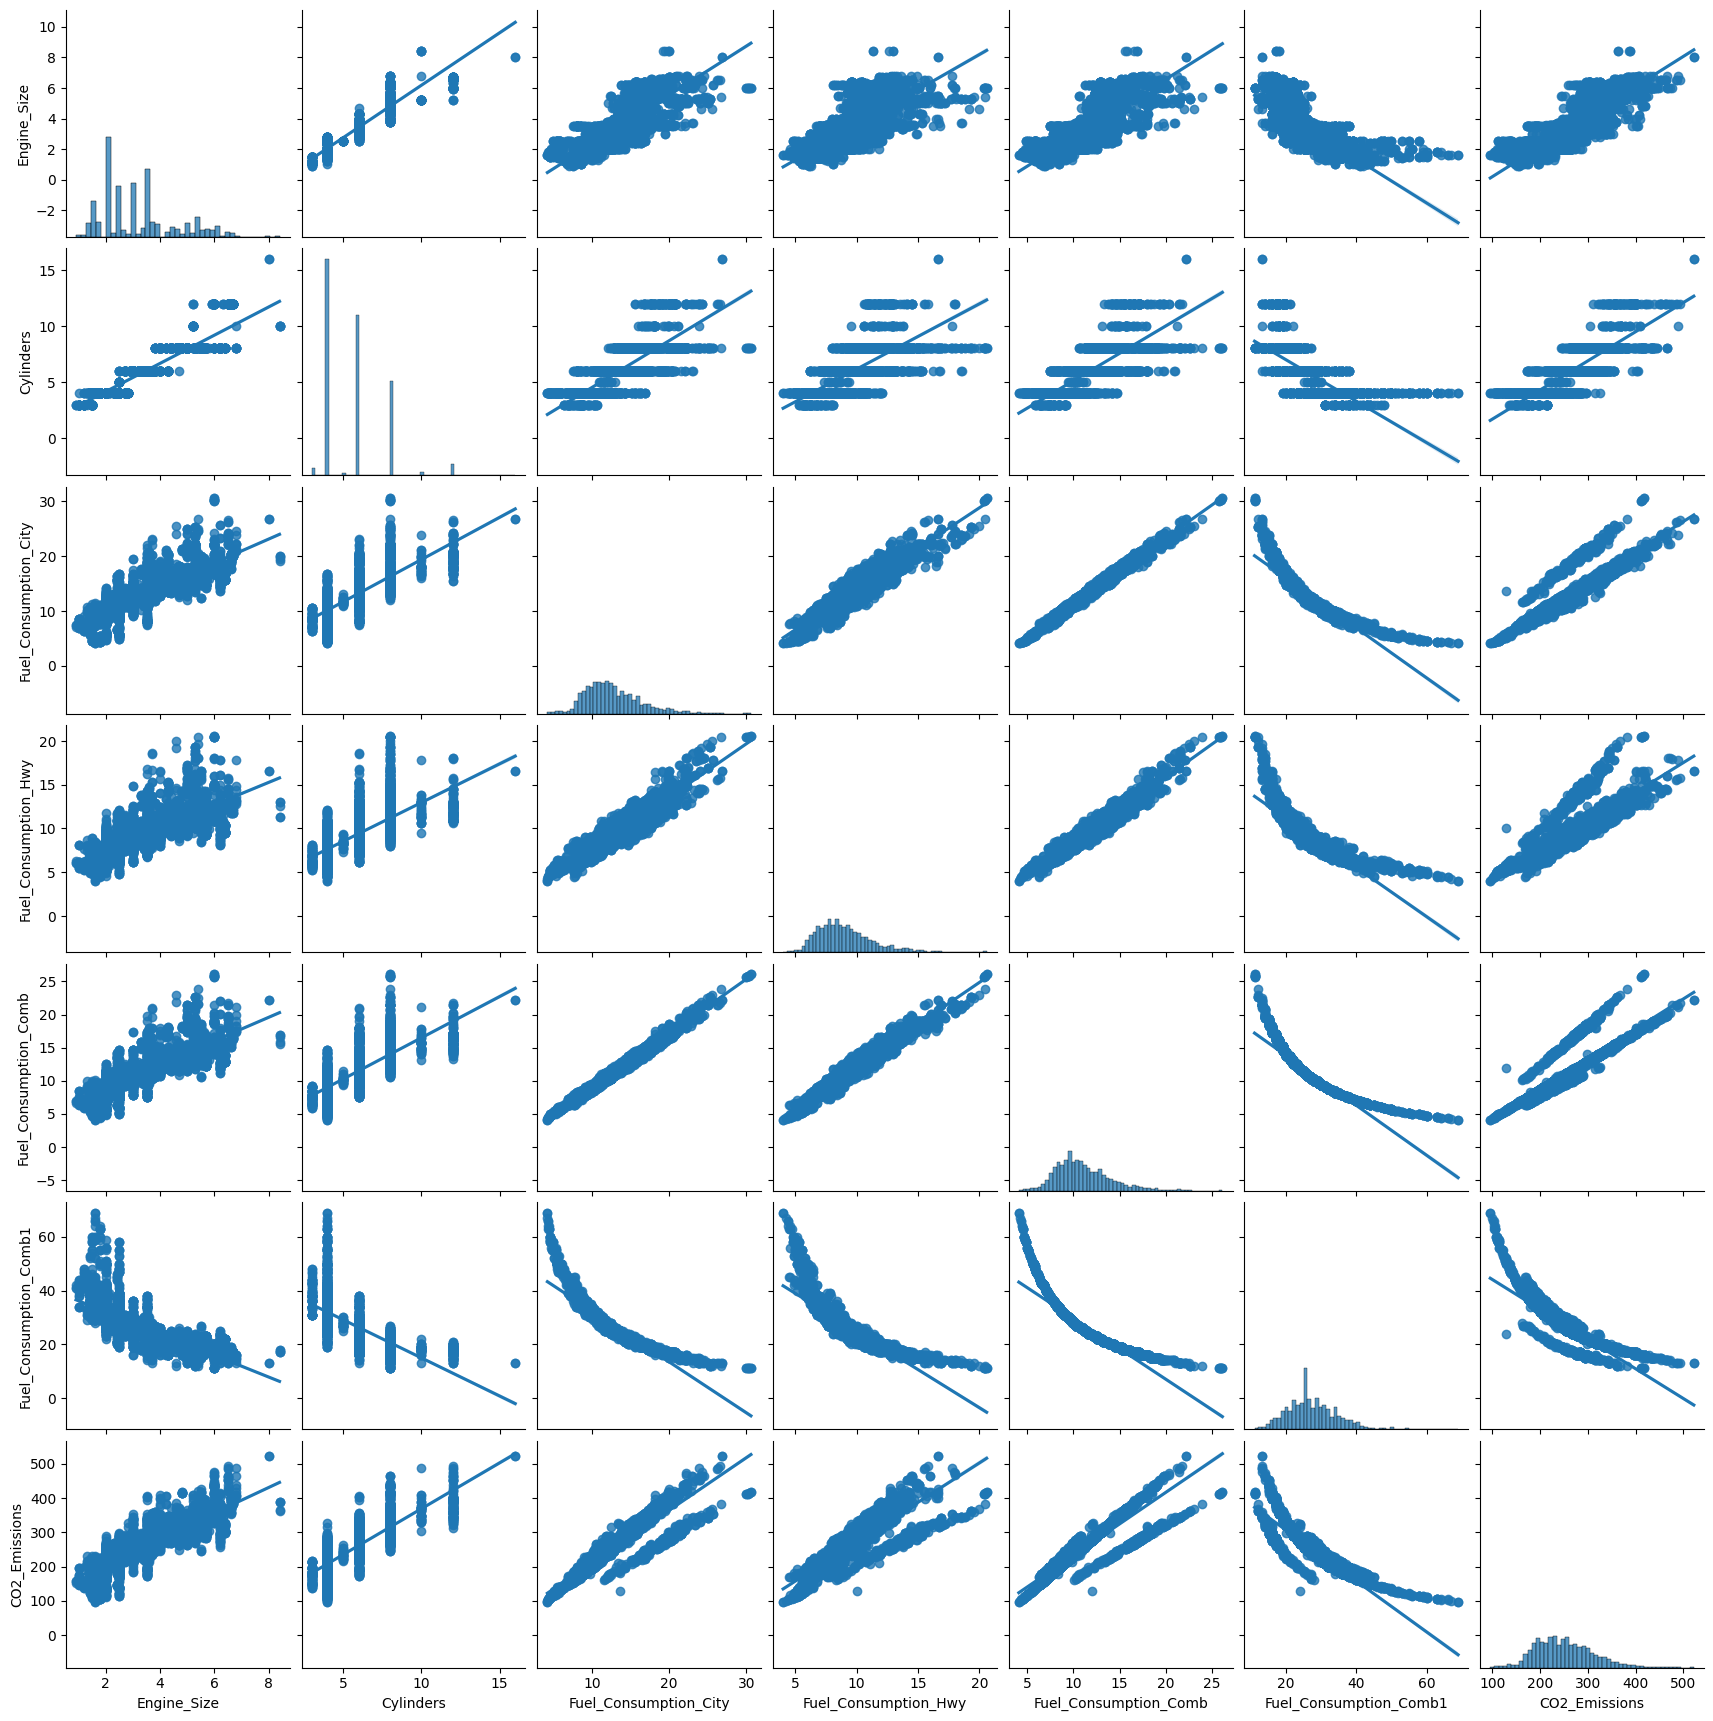

In [35]:
plt.figure(figsize=(10,5))
sns.pairplot(data,kind="reg")
plt.show()

1. Fuel_Consumption_Comb1 shows a negative relation with all the other numerical variables
2. Fuel_Consumption_City and Fuel_Consumption_Hwy are strongly postively related

### 4.2.6 Feature Engineering <a id='feature_eng'></a>

Create a new feature Make_Type by combining various car companies(Make) on the basis of their functionality
<br>
There are 42 unique Car Companies. We will divide these companies into Luxury, Sports, Premium and General cars

In [36]:
data['Make_Type'] = data['Make'].replace(['BUGATTI', 'PORSCHE', 'MASERATI', 'ASTON MARTIN', 'LAMBORGHINI', 'JAGUAR','SRT'], 'Sports')
data['Make_Type'] = data['Make_Type'].replace(['ALFA ROMEO', 'AUDI', 'BMW', 'BUICK', 'CADILLAC', 'CHRYSLER', 'DODGE', 'GMC','INFINITI', 'JEEP', 'LAND ROVER', 'LEXUS', 'MERCEDES-BENZ','MINI', 'SMART', 'VOLVO'],'Premium')
data['Make_Type'] = data['Make_Type'].replace(['ACURA', 'BENTLEY', 'LINCOLN', 'ROLLS-ROYCE',  'GENESIS'], 'Luxury')
data['Make_Type'] = data['Make_Type'].replace(['CHEVROLET', 'FIAT', 'FORD', 'KIA', 'HONDA', 'HYUNDAI', 'MAZDA', 'MITSUBISHI','NISSAN', 'RAM', 'SCION', 'SUBARU', 'TOYOTA','VOLKSWAGEN'],'General')

In [37]:
data.drop(['Make'], inplace=True, axis=1)

data['Make_Type'].unique()

array(['Luxury', 'Premium', 'Sports', 'General'], dtype=object)

In [38]:
data['Make_Type'].value_counts()

,count
Make_Type,
General,2776
Premium,2731
Sports,546
Luxury,229


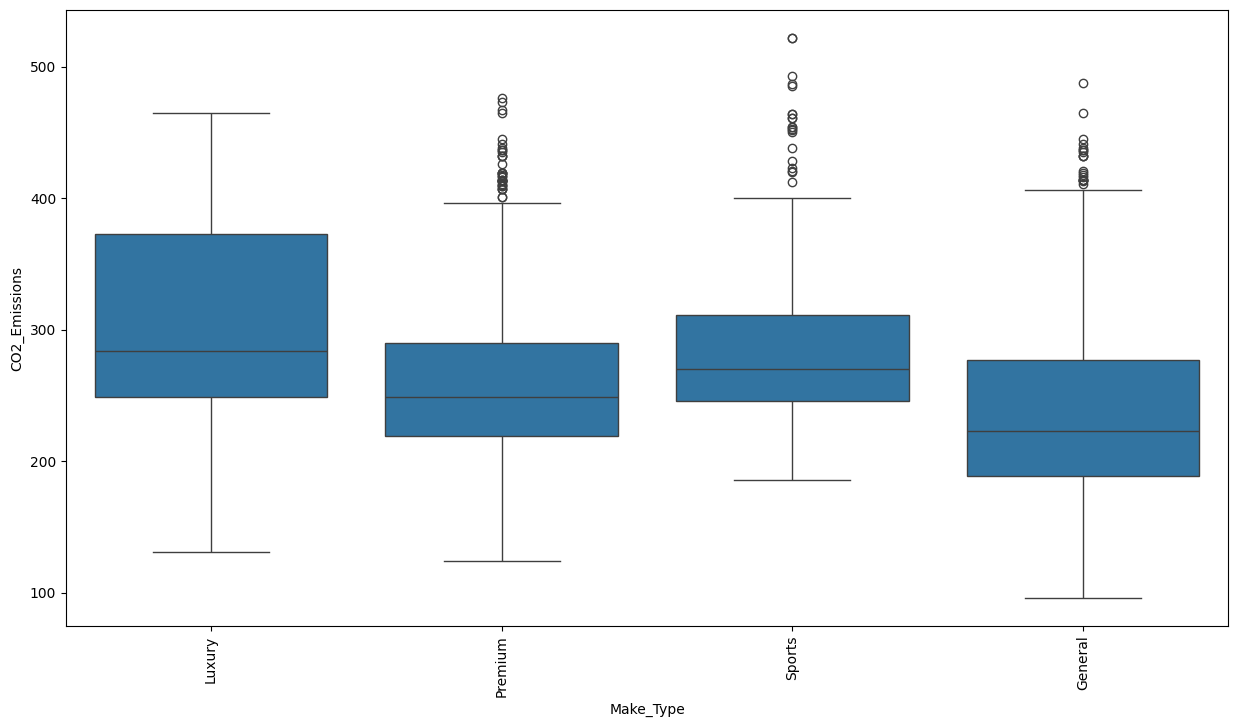

In [39]:
plt.figure(figsize=(15,8))
ax = sns.boxplot(x="Make_Type", y="CO2_Emissions", data=data)
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)
plt.show()

The plot shows that Sports cars and Luxury cars emit more CO2 compared to Premium and General use cars

Create a new feature Vehicle_Class_Type by combining various Vehicle_Class on the basis of their size
<br>
There are 16 unique Vehicle Classes. We will divide them into Hatchback, Sedan, SUV and Truck

In [40]:
data['Vehicle_Class_Type'] = data['Vehicle_Class'].replace(['COMPACT', 'MINICOMPACT', 'SUBCOMPACT'], 'Hatchback')
data['Vehicle_Class_Type'] = data['Vehicle_Class_Type'].replace(['MID-SIZE', 'TWO-SEATER', 'FULL-SIZE', 'STATION WAGON - SMALL', 'STATION WAGON - MID-SIZE'],'Sedan')
data['Vehicle_Class_Type'] = data['Vehicle_Class_Type'].replace(['SUV - SMALL', 'SUV - STANDARD', 'MINIVAN'],  'SUV')
data['Vehicle_Class_Type'] = data['Vehicle_Class_Type'].replace(['VAN - CARGO', 'VAN - PASSENGER', 'PICKUP TRUCK - STANDARD', 'SPECIAL PURPOSE VEHICLE', 'PICKUP TRUCK - SMALL'], 'Truck')

In [41]:
data.drop(['Vehicle_Class'], inplace=True,  axis=1)

data['Vehicle_Class_Type'].unique()

array(['Hatchback', 'SUV', 'Sedan', 'Truck'], dtype=object)

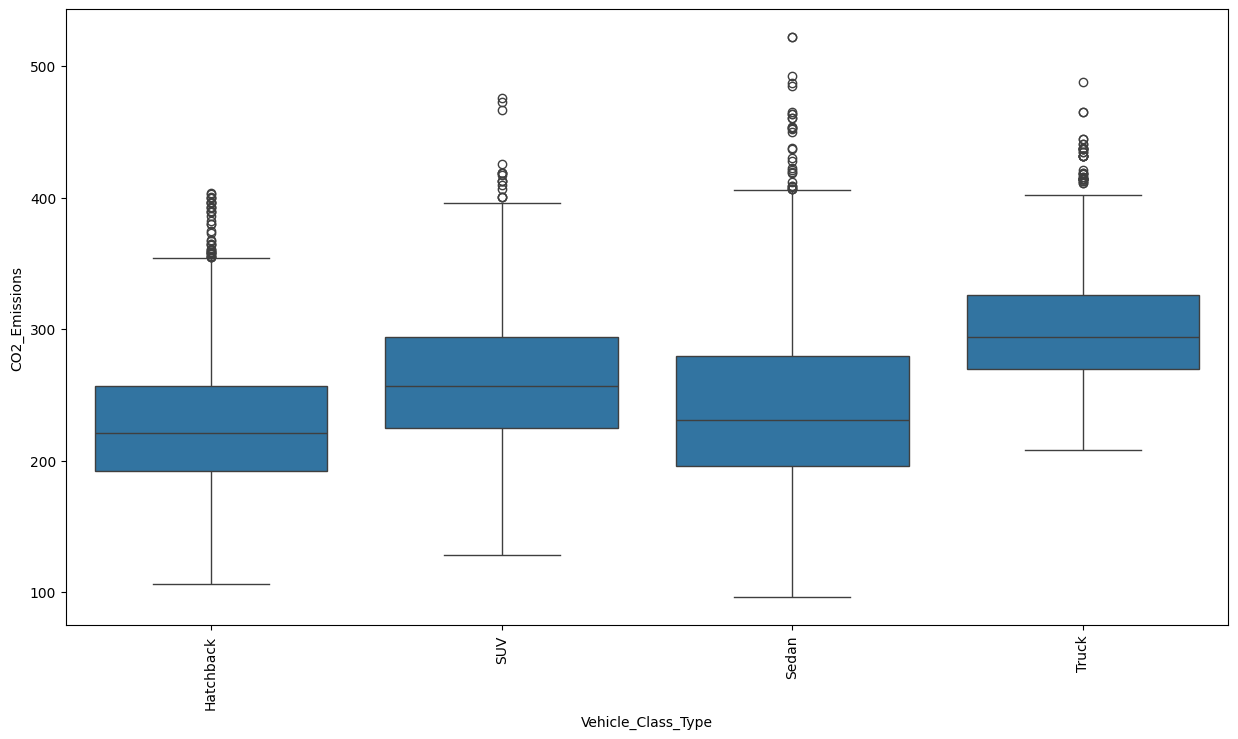

In [42]:
plt.figure(figsize=(15,8))
ax = sns.boxplot(x="Vehicle_Class_Type", y="CO2_Emissions", data=data)
ax.set_xticklabels(labels=ax.get_xticklabels(), rotation=90)
plt.show()

The plot shows that the bigger the cars are the more CO2 they emit

# 5. Data Preprocessing <a id='data_pre'></a>

In [43]:
data.drop(['Model'],axis=1,inplace=True)

Since Model has 2053 unique values and has no significance with respect to CO2 Emissions , we have dropped this column

## 5.1 Outliers <a id='out'></a>

### 5.1.1 Discovery of Outliers<a id='dis_out'></a>

In [52]:
df_num_features=data.select_dtypes(include=np.number)

**Identifying outliers using IQR**

In [53]:
Q1 = df_num_features.quantile(0.25)
Q3 = df_num_features.quantile(0.75)
IQR = Q3 - Q1
print(IQR)

Engine_Size               1.600000
Cylinders                 2.000000
Fuel_Consumption_City     4.100000
Fuel_Consumption_Hwy      2.500000
Fuel_Consumption_Comb     3.400000
Fuel_Consumption_Comb1    9.000000
CO2_Emissions            74.000000
dtype: float64


In [54]:
outlier = pd.DataFrame((df_num_features < (Q1 - 1.5 * IQR)) | (df_num_features > (Q3 + 1.5 * IQR)))

for i in outlier.columns:
    print('Total number of Outliers in column {} are {}'.format(i, (len(outlier[outlier[i] == True][i]))))

Total number of Outliers in column Engine_Size are 134
Total number of Outliers in column Cylinders are 0
Total number of Outliers in column Fuel_Consumption_City are 39
Total number of Outliers in column Fuel_Consumption_Hwy are 112
Total number of Outliers in column Fuel_Consumption_Comb are 35
Total number of Outliers in column Fuel_Consumption_Comb1 are 16
Total number of Outliers in column CO2_Emissions are 10


**Visualizing outliers using Boxplots**

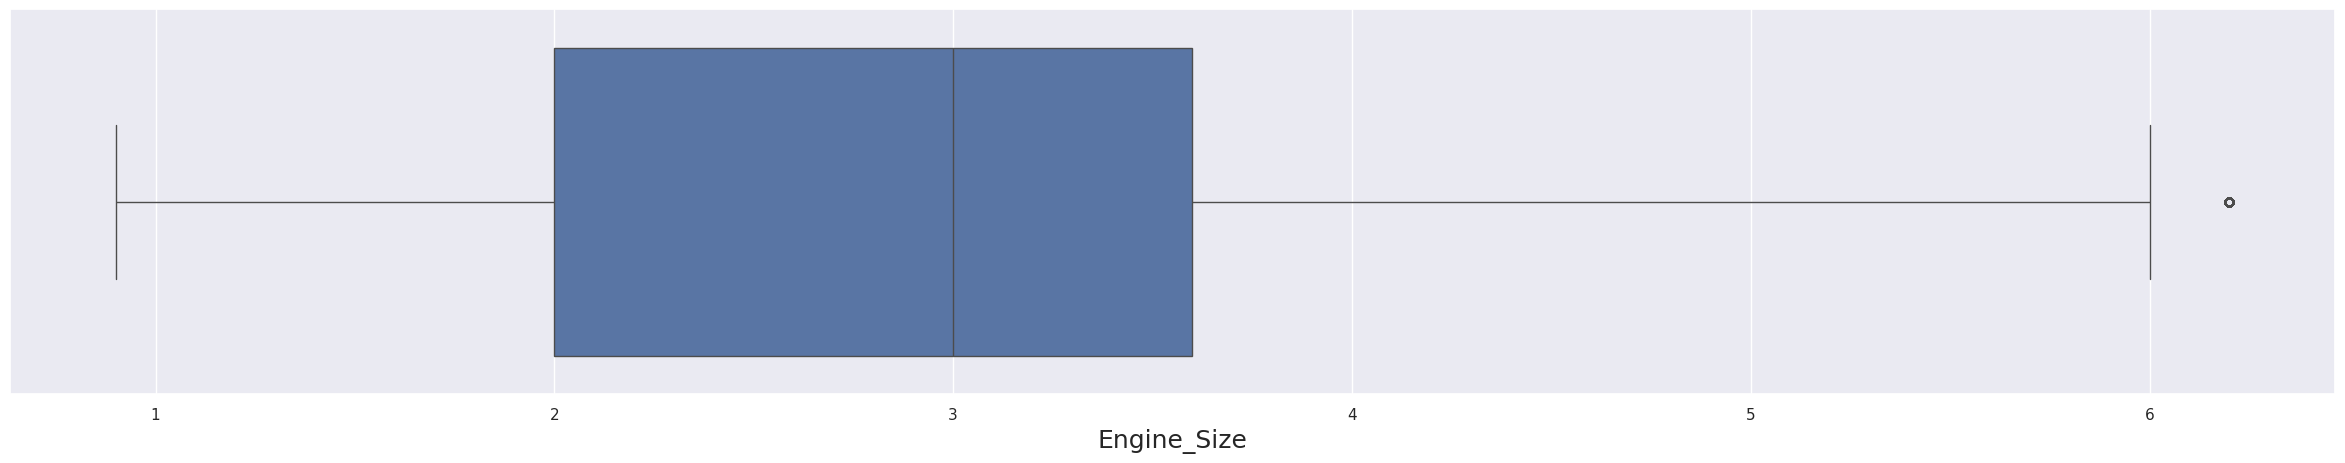

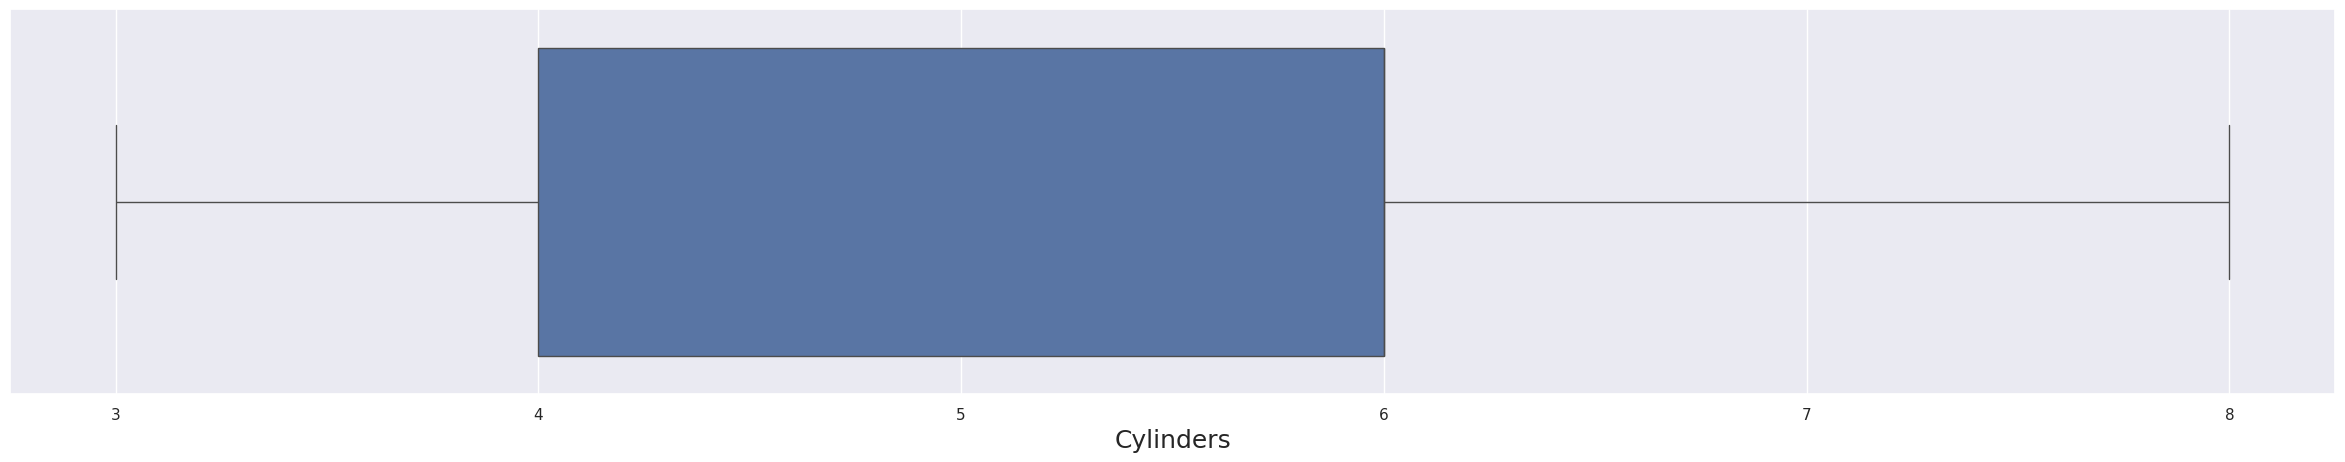

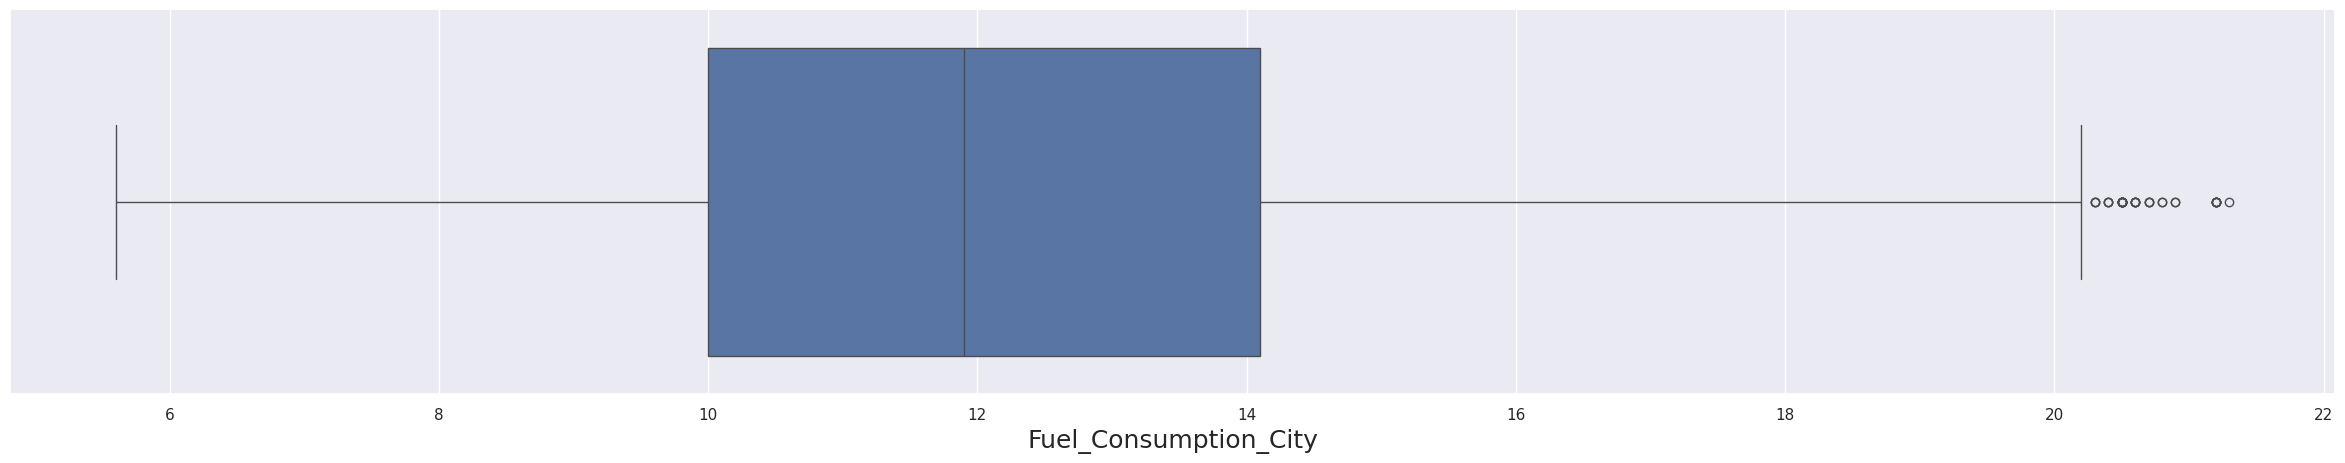

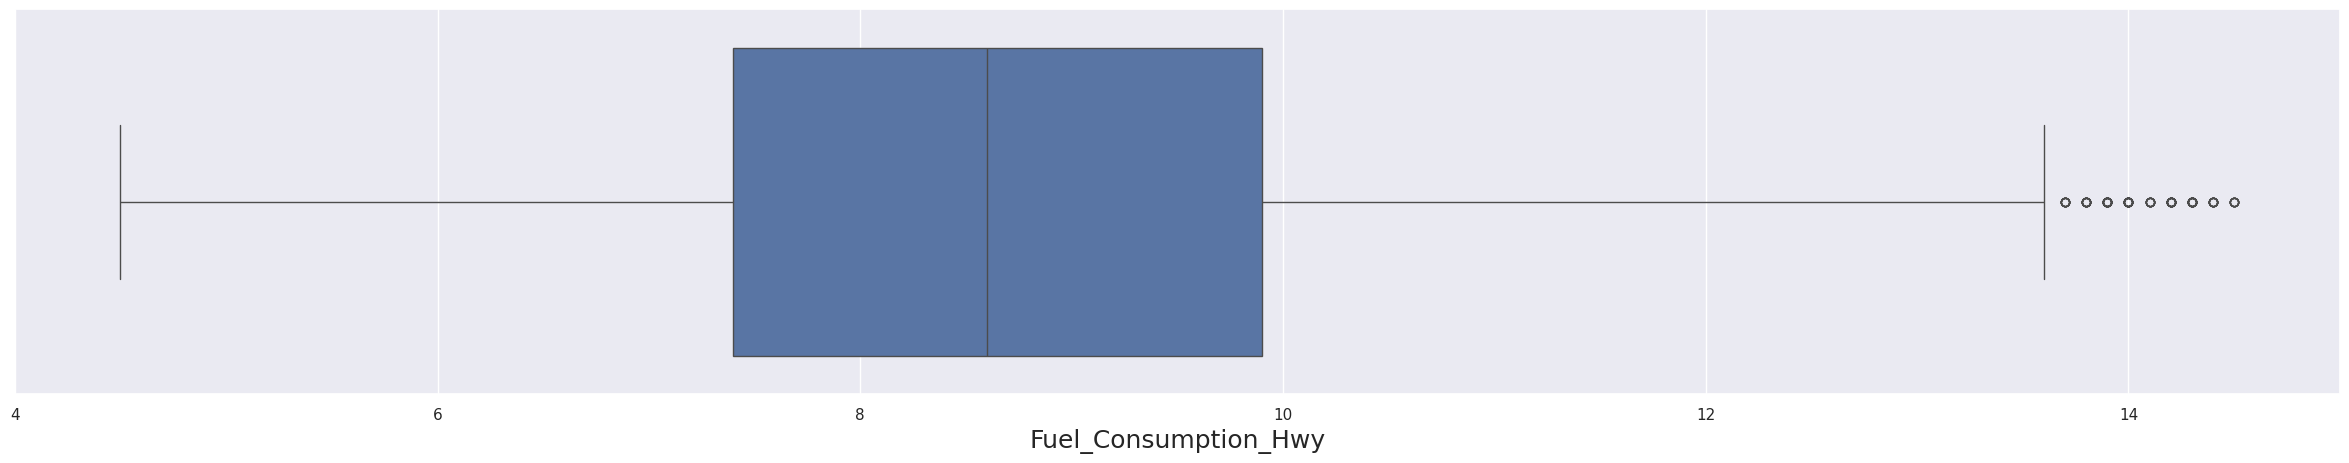

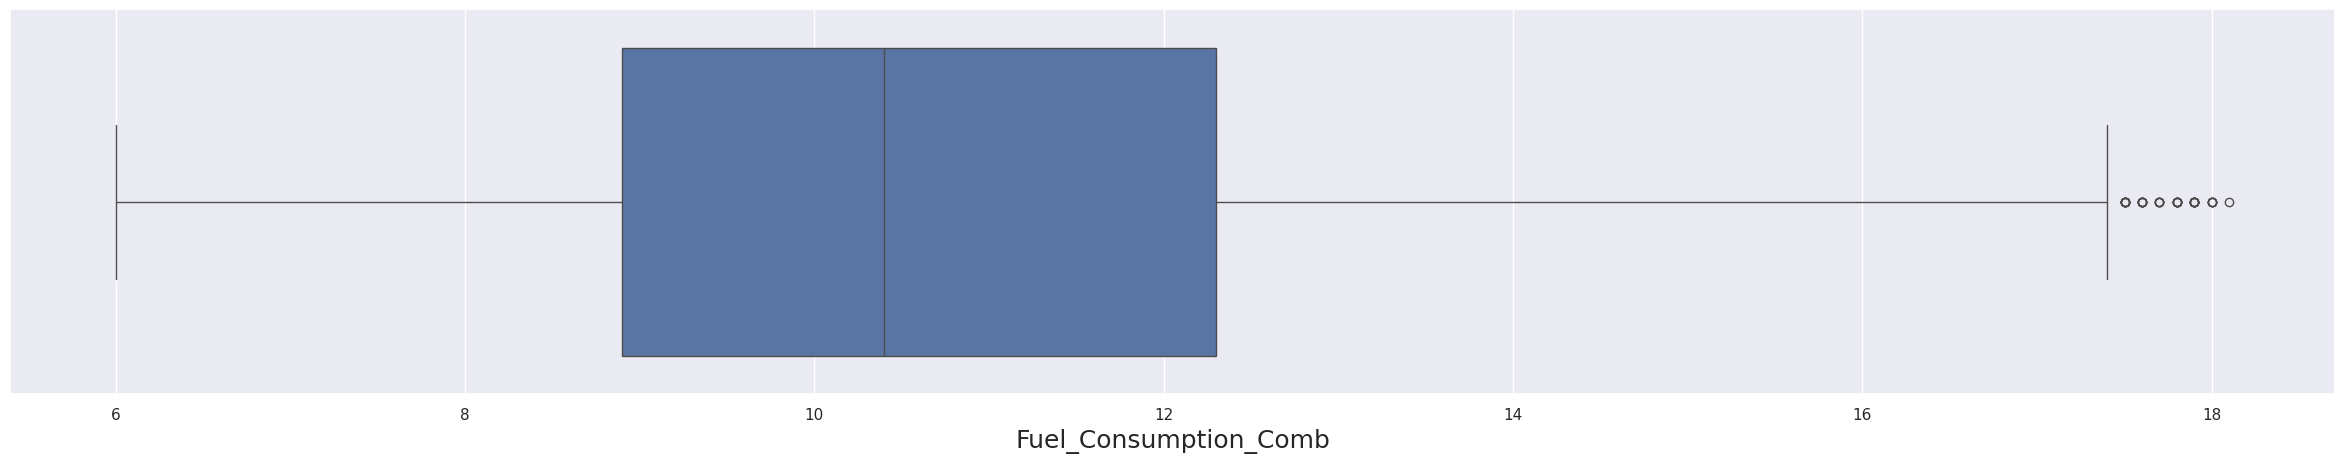

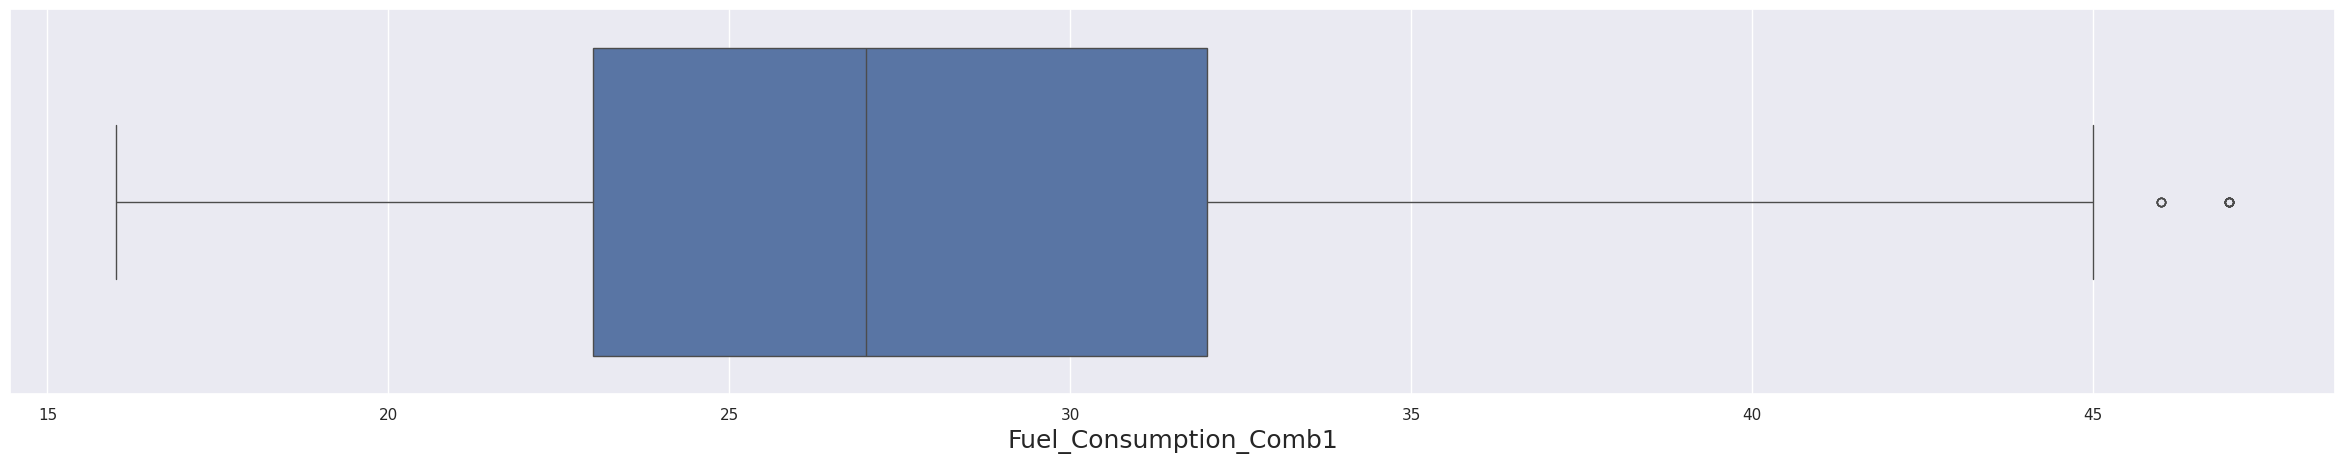

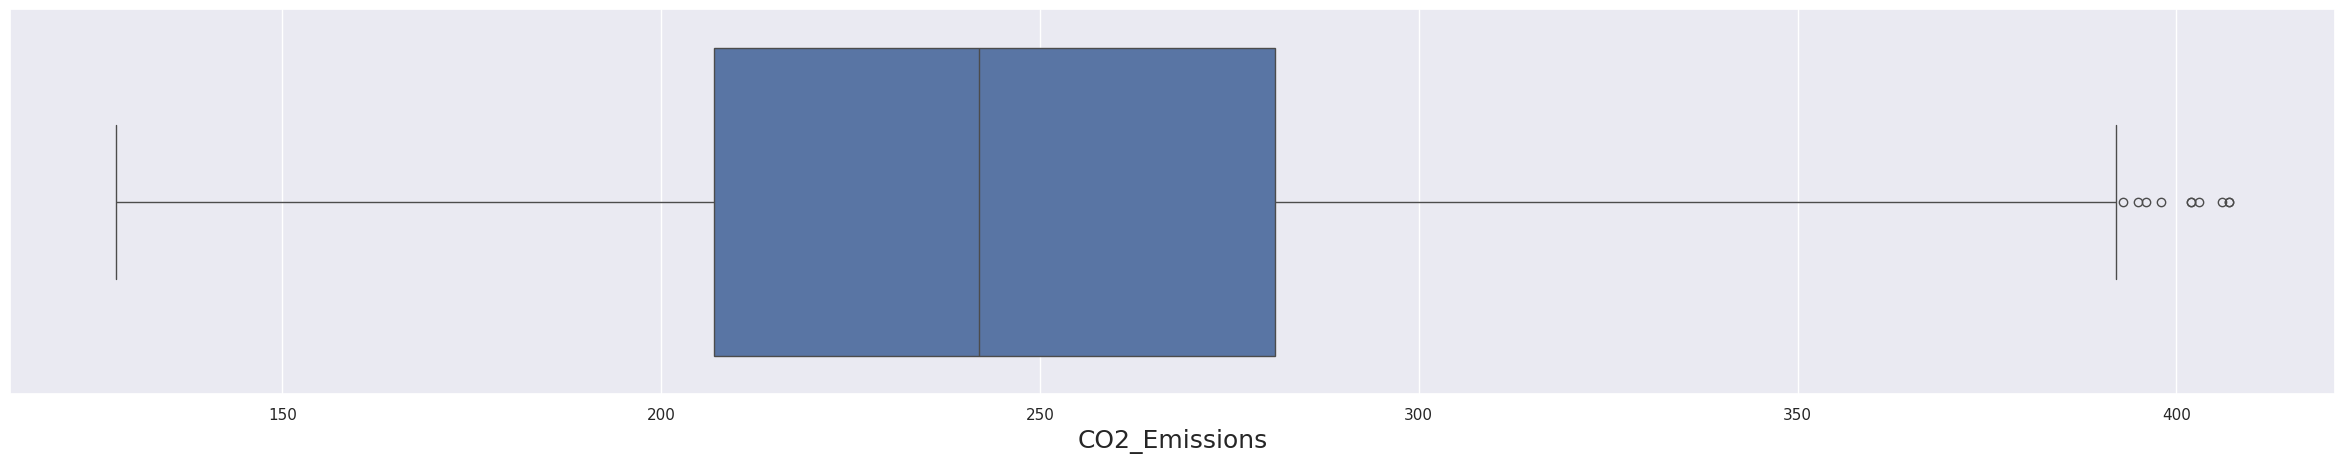

In [55]:
for column in enumerate(df_num_features):
    plt.figure(figsize=(30,5))
    sns.set_theme(style="darkgrid")
    sns.boxplot(x=column[1], data=  df_num_features)
    plt.xlabel(column[1],fontsize=18)
    plt.show()

### 5.1.2 Removal of Outliers<a id='rem_out'></a>

**Checking the normality of numeric features**

In [56]:
stat, p_value = shapiro(df_num_features)

print('Test statistic:', stat)
print('P-Value:', p_value)

Test statistic: 0.5194042655738959
P-Value: 6.927471763833758e-135


Since the numeric features are not normal we are removing the outliers using IQR method

In [69]:
data = data[~outlier.any(axis=1)]
data.reset_index(inplace=True, drop=True)

### 5.1.3 Re-checking Correlation<a id='rec_cor'></a>

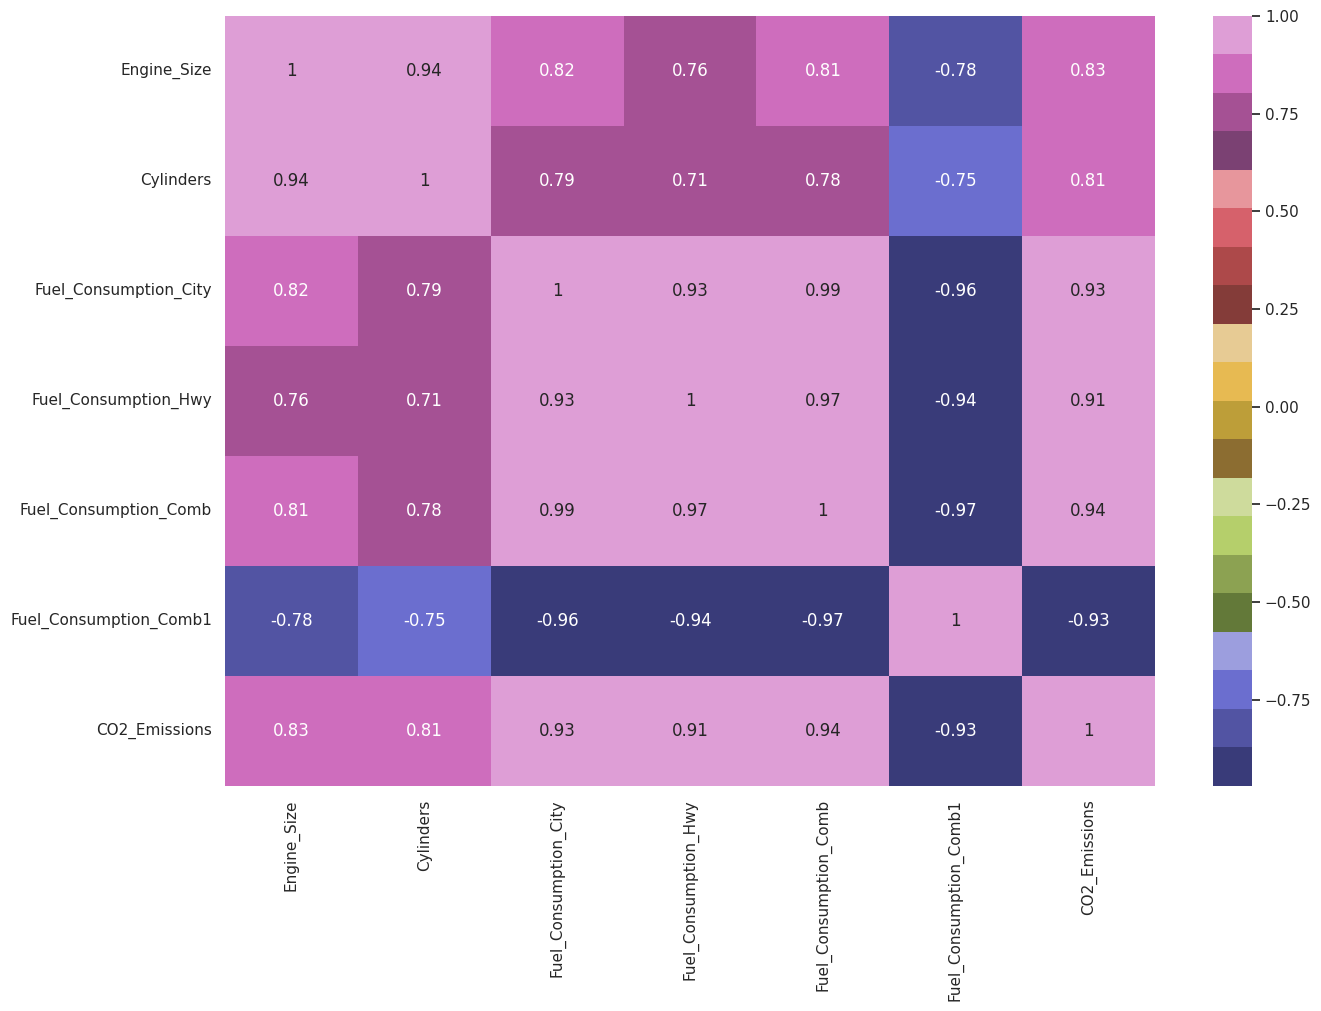

In [58]:
data_num_features = data.select_dtypes(include=np.number)

corr =  data_num_features.corr()

corr =data_num_features.corr(method='pearson')
sns.heatmap(corr, annot=True,cmap='tab20b')
plt.show()

There has been a slight change with respect to the correlation between numeric values

## 5.2 Categorical Encoding<a id='cat_enc'></a>

In [70]:
df_dummies = pd.get_dummies(data = data[["Fuel_Type","Transmission","Make_Type","Vehicle_Class_Type"]], drop_first = True, dtype=int)

df_num_features=data.select_dtypes(include=np.number)

df_comb = pd.concat([df_num_features, df_dummies], axis = 1)

In [60]:
df_comb.head()

,Engine_Size,Cylinders,Fuel_Consumption_City,Fuel_Consumption_Hwy,Fuel_Consumption_Comb,Fuel_Consumption_Comb1,CO2_Emissions,Fuel_Type_E,Fuel_Type_N,Fuel_Type_X,Fuel_Type_Z,Transmission_A4,Transmission_A5,Transmission_A6,Transmission_A7,Transmission_A8,Transmission_A9,Transmission_AM5,Transmission_AM6,Transmission_AM7,Transmission_AM8,Transmission_AM9,Transmission_AS10,Transmission_AS4,Transmission_AS5,Transmission_AS6,Transmission_AS7,Transmission_AS8,Transmission_AS9,Transmission_AV,Transmission_AV10,Transmission_AV6,Transmission_AV7,Transmission_AV8,Transmission_M5,Transmission_M6,Transmission_M7,Make_Type_Luxury,Make_Type_Premium,Make_Type_Sports,Vehicle_Class_Type_SUV,Vehicle_Class_Type_Sedan,Vehicle_Class_Type_Truck
0,2.000000,4,9.900000,6.700000,8.500000,33,196,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
1,2.400000,4,11.200000,7.700000,9.600000,29,221,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False
2,3.500000,6,12.700000,9.100000,11.100000,25,255,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False
3,3.500000,6,12.100000,8.700000,10.600000,27,244,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False
4,3.500000,6,11.900000,7.700000,10.000000,28,230,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False


In [109]:
df_comb.head()

,Engine_Size,Cylinders,Fuel_Consumption_City,Fuel_Consumption_Hwy,Fuel_Consumption_Comb,Fuel_Consumption_Comb1,CO2_Emissions,Fuel_Type_E,Fuel_Type_N,Fuel_Type_X,Fuel_Type_Z,Transmission_A4,Transmission_A5,Transmission_A6,Transmission_A7,Transmission_A8,Transmission_A9,Transmission_AM5,Transmission_AM6,Transmission_AM7,Transmission_AM8,Transmission_AM9,Transmission_AS10,Transmission_AS4,Transmission_AS5,Transmission_AS6,Transmission_AS7,Transmission_AS8,Transmission_AS9,Transmission_AV,Transmission_AV10,Transmission_AV6,Transmission_AV7,Transmission_AV8,Transmission_M5,Transmission_M6,Transmission_M7,Make_Type_Luxury,Make_Type_Premium,Make_Type_Sports,Vehicle_Class_Type_SUV,Vehicle_Class_Type_Sedan,Vehicle_Class_Type_Truck
0,2.000000,4,9.900000,6.700000,8.500000,33,196,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,2.400000,4,11.200000,7.700000,9.600000,29,221,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0
2,3.500000,6,12.700000,9.100000,11.100000,25,255,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0
3,3.500000,6,12.100000,8.700000,10.600000,27,244,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0
4,3.500000,6,11.900000,7.700000,10.000000,28,230,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0


# 6. Multiple Linear Regression Models<a id='bui_mlr_mod'></a>

In [72]:
X = df_comb.drop(['CO2_Emissions'], axis=1)
y = df_comb['CO2_Emissions']

## 6.1 Multiple Linear Regression - Basic Model<a id='bas_mod'></a>

In [73]:
X = sm.add_constant(X)

In [74]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

In [75]:
MLR_model1 = sm.OLS(y_train, X_train).fit()
MLR_model1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          CO2_Emissions   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 1.865e+04
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:28:55   Log-Likelihood:                -9552.8
No. Observations:                3697   AIC:                         1.919e+04
Df Residuals:                    3654   BIC:                         1.946e+04
Df Model:                          42                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       63.3851      2.774     22.853      0.000      57.947      68.823
Engine_Size                  0.1533      0.174      0.880      0.379      -0.188       0.495
Cylinders                    0.1898      0.124      1.526      0.127      -0.054       0.434
Fuel_Consumption_City        5.8842      0.720      8.176      0.000       4.473       7.295
Fuel_Consumption_Hwy         5.5661      0.597      9.331      0.000       4.397       6.736
Fuel_Consumption_Comb       10.3213      1.306      7.901      0.000       7.760      12.883
Fuel_Consumption_Comb1      -0.5574      0.044    -12.531      0.000      -0.645      -0.470
Fuel_Type_E               -130.1404      0.575   -226.455      0.000    -131.267    -129.014
Fuel_Type_N               -111.6675      3.257    -34.289      0.000    -118.053    -105.282
Fuel_Type_X                -30.2442      0.356    -84.847      0.000     -30.943     -29.545
Fuel_Type_Z                -30.7835      0.380    -81.066      0.000     -31.528     -30.039
Transmission_A4             -2.7842      1.508     -1.847      0.065      -5.740       0.171
Transmission_A5             -2.3253      1.340     -1.736      0.083      -4.952       0.301
Transmission_A6             -1.8642      1.258     -1.482      0.139      -4.331       0.603
Transmission_A7              0.1639      1.421      0.115      0.908      -2.623       2.951
Transmission_A8             -0.8148      1.261     -0.646      0.518      -3.287       1.657
Transmission_A9              0.3314      1.273      0.260      0.795      -2.165       2.828
Transmission_AM5             0.1495      2.069      0.072      0.942      -3.906       4.205
Transmission_AM6            -1.4780      1.323     -1.117      0.264      -4.072       1.116
Transmission_AM7            -0.6230      1.276     -0.488      0.625      -3.125       1.879
Transmission_AM8            -0.5341      1.397     -0.382      0.702      -3.272       2.204
Transmission_AM9             2.3129      3.494      0.662      0.508      -4.537       9.163
Transmission_AS10            0.1973      1.285      0.154      0.878      -2.322       2.716
Transmission_AS4            -4.1735      3.468     -1.204      0.229     -10.972       2.625
Transmission_AS5            -3.4968      1.486     -2.354      0.019      -6.410      -0.584
Transmission_AS6            -1.4268      1.261     -1.131      0.258      -3.900       1.046
Transmission_AS7            -1.5742      1.274     -1.235      0.217      -4.073       0.924
Transmission_AS8            -0.2955      1.258     -0.235      0.814      -2.762       2.171
Transmission_AS9            -0.2141      1.347     -0.159      0.874      -2.854       2.426
Transmission_AV             -0.9790      1.292     -0.758      0.449      -3.512       1.554
Transmission_A

1. 99.5% of the variation is dependent on variable CO2_Emissions.
2. The Durbin-Watson test statistic is 2.006 and indicates that there is no auto-correlation
3. The Condition Number is 1.00e+16 which suggests that there is severe mutli-collinearity
4. The features taken into consideration are of different scales

## 6.2 Feature Transformation<a id='fea_tra'></a>

In [76]:
df_num_features.skew()

,0
Engine_Size,0.703517
Cylinders,0.581731
Fuel_Consumption_City,0.405381
Fuel_Consumption_Hwy,0.503375
Fuel_Consumption_Comb,0.427581
Fuel_Consumption_Comb1,0.415979
CO2_Emissions,0.353757


Since the skewness is relatively low, there is no need to perform any further transformations to reduce skewness

## 6.3 Feature Scaling<a id='fea_sca'></a>

In [77]:
for col in df_num_features.columns:
    print("Column ", col, " :", stats.shapiro(df_num_features[col]))

Column  Engine_Size  : ShapiroResult(statistic=np.float64(0.9299183908722556), pvalue=np.float64(2.4764728375849134e-44))
Column  Cylinders  : ShapiroResult(statistic=np.float64(0.7891564856790609), pvalue=np.float64(9.871157978099711e-64))
Column  Fuel_Consumption_City  : ShapiroResult(statistic=np.float64(0.9814634517716239), pvalue=np.float64(9.822745018319365e-26))
Column  Fuel_Consumption_Hwy  : ShapiroResult(statistic=np.float64(0.977857264054698), pvalue=np.float64(6.476222586160716e-28))
Column  Fuel_Consumption_Comb  : ShapiroResult(statistic=np.float64(0.9799720226608559), pvalue=np.float64(1.1333916385321804e-26))
Column  Fuel_Consumption_Comb1  : ShapiroResult(statistic=np.float64(0.9782230278609829), pvalue=np.float64(1.0463161574965965e-27))
Column  CO2_Emissions  : ShapiroResult(statistic=np.float64(0.9829678550586867), pvalue=np.float64(9.945613685400535e-25))


Since none of the numerical features are normally distributed (p-value<0.05) , we will perform Min-Max normalisation to scale the data

In [78]:
df_num_features.drop('CO2_Emissions',axis=1,inplace=True)

In [79]:
mms = MinMaxScaler()
mmsfit = mms.fit(df_num_features)
dfx = pd.DataFrame(mms.fit_transform(df_num_features), columns = ['Engine_Size','Cylinders','Fuel_Consumption_City',
                                                                'Fuel_Consumption_Hwy','Fuel_Consumption_Comb','Fuel_Consumption_Comb1'])

In [80]:
df = pd.concat([dfx, df_dummies], axis = 1)
df.head()

,Engine_Size,Cylinders,Fuel_Consumption_City,Fuel_Consumption_Hwy,Fuel_Consumption_Comb,Fuel_Consumption_Comb1,Fuel_Type_E,Fuel_Type_N,Fuel_Type_X,Fuel_Type_Z,Transmission_A4,Transmission_A5,Transmission_A6,Transmission_A7,Transmission_A8,Transmission_A9,Transmission_AM5,Transmission_AM6,Transmission_AM7,Transmission_AM8,Transmission_AM9,Transmission_AS10,Transmission_AS4,Transmission_AS5,Transmission_AS6,Transmission_AS7,Transmission_AS8,Transmission_AS9,Transmission_AV,Transmission_AV10,Transmission_AV6,Transmission_AV7,Transmission_AV8,Transmission_M5,Transmission_M6,Transmission_M7,Make_Type_Luxury,Make_Type_Premium,Make_Type_Sports,Vehicle_Class_Type_SUV,Vehicle_Class_Type_Sedan,Vehicle_Class_Type_Truck
0,0.215686,0.200000,0.264286,0.241758,0.201835,0.586207,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
1,0.294118,0.200000,0.357143,0.351648,0.302752,0.448276,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0
2,0.509804,0.600000,0.464286,0.505495,0.440367,0.310345,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0
3,0.509804,0.600000,0.421429,0.461538,0.394495,0.379310,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0
4,0.509804,0.600000,0.407143,0.351648,0.339450,0.413793,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0


## 6.4 Multiple Linear Regression -  After Feature Scaling<a id='mod_aft_sca'></a>

In [81]:
X = df.copy()
X = sm.add_constant(X)

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)


MLR_model2 = sm.OLS(y_train, X_train).fit()
MLR_model2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          CO2_Emissions   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 1.865e+04
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:28:55   Log-Likelihood:                -9552.8
No. Observations:                3697   AIC:                         1.919e+04
Df Residuals:                    3654   BIC:                         1.946e+04
Df Model:                          42                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                      181.7278      1.957     92.870      0.000     177.891     185.564
Engine_Size                  0.7818      0.888      0.880      0.379      -0.959       2.523
Cylinders                    0.9492      0.622      1.526      0.127      -0.270       2.168
Fuel_Consumption_City       82.3781     10.075      8.176      0.000      62.624     102.132
Fuel_Consumption_Hwy        50.6519      5.428      9.331      0.000      40.009      61.295
Fuel_Consumption_Comb      112.5027     14.239      7.901      0.000      84.585     140.421
Fuel_Consumption_Comb1     -16.1649      1.290    -12.531      0.000     -18.694     -13.636
Fuel_Type_E               -130.1404      0.575   -226.455      0.000    -131.267    -129.014
Fuel_Type_N               -111.6675      3.257    -34.289      0.000    -118.053    -105.282
Fuel_Type_X                -30.2442      0.356    -84.847      0.000     -30.943     -29.545
Fuel_Type_Z                -30.7835      0.380    -81.066      0.000     -31.528     -30.039
Transmission_A4             -2.7842      1.508     -1.847      0.065      -5.740       0.171
Transmission_A5             -2.3253      1.340     -1.736      0.083      -4.952       0.301
Transmission_A6             -1.8642      1.258     -1.482      0.139      -4.331       0.603
Transmission_A7              0.1639      1.421      0.115      0.908      -2.623       2.951
Transmission_A8             -0.8148      1.261     -0.646      0.518      -3.287       1.657
Transmission_A9              0.3314      1.273      0.260      0.795      -2.165       2.828
Transmission_AM5             0.1495      2.069      0.072      0.942      -3.906       4.205
Transmission_AM6            -1.4780      1.323     -1.117      0.264      -4.072       1.116
Transmission_AM7            -0.6230      1.276     -0.488      0.625      -3.125       1.879
Transmission_AM8            -0.5341      1.397     -0.382      0.702      -3.272       2.204
Transmission_AM9             2.3129      3.494      0.662      0.508      -4.537       9.163
Transmission_AS10            0.1973      1.285      0.154      0.878      -2.322       2.716
Transmission_AS4            -4.1735      3.468     -1.204      0.229     -10.972       2.625
Transmission_AS5            -3.4968      1.486     -2.354      0.019      -6.410      -0.584
Transmission_AS6            -1.4268      1.261     -1.131      0.258      -3.900       1.046
Transmission_AS7            -1.5742      1.274     -1.235      0.217      -4.073       0.924
Transmission_AS8            -0.2955      1.258     -0.235      0.814      -2.762       2.171
Transmission_AS9            -0.2141      1.347     -0.159      0.874      -2.854       2.426
Transmission_AV             -0.9790      1.292     -0.758      0.449      -3.512       1.554
Transmission_A

1. 99.5% of the variation is dependent on variable CO2_Emissions.
2. The Durbin-Watson test statistic is 2.006 and indicates that there is no auto-correlation
3. The Condition Number is 1.24e+16 which suggests that there is severe mutli-collinearity

## 6.5 Assumptions Before Multiple Linear Regression Model<a id="ass_bef"></a>

### 6.5.1 Assumption #1: If Target Variable is Numeric<a id="tgt_num"></a>

In [98]:
target = df_comb['CO2_Emissions']
target.dtype

dtype('int64')

### 6.5.2 Assumption #2: Presence of Multi-Collinearity<a id="pre_mul_col"></a>

In [99]:
vif = pd.DataFrame()
vif["VIF_Factor"] = [variance_inflation_factor(df_num_features.values, i) for i in range(df_num_features.shape[1])]
vif["Features"] = df_num_features.columns
vif.sort_values('VIF_Factor', ascending = False).reset_index(drop = True)

,VIF_Factor,Features
0,63816.816519,Fuel_Consumption_Comb
1,25502.102789,Fuel_Consumption_City
2,8993.163720,Fuel_Consumption_Hwy
3,126.487444,Cylinders
4,78.576946,Engine_Size
5,11.004049,Fuel_Consumption_Comb1


Since all the features except Fuel_Consumption_Comb1 have a VIF value greater than 10 we cannot proceed with VIF method else we will lose all our features. Hence , we will proceed with PCA

In [100]:
sklearn_pca = PCA()
pcafit = sklearn_pca.fit(df)

pcafit.explained_variance_

array([6.26932065e-01, 3.39946776e-01, 2.43568856e-01, 2.01215506e-01,
       1.70122898e-01, 1.52969801e-01, 1.24893527e-01, 9.74413861e-02,
       7.54270910e-02, 5.90230295e-02, 5.43111395e-02, 4.73302290e-02,
       4.15894310e-02, 3.95103369e-02, 3.58246914e-02, 3.03492414e-02,
       2.68446040e-02, 2.33108209e-02, 2.31015862e-02, 1.84809579e-02,
       1.73825950e-02, 1.53587139e-02, 1.41257175e-02, 1.22560716e-02,
       1.10151606e-02, 9.82705854e-03, 7.61454861e-03, 6.51367566e-03,
       5.91856622e-03, 5.37048828e-03, 5.13273468e-03, 4.69211286e-03,
       2.67176157e-03, 1.60608408e-03, 1.35219830e-03, 9.71261666e-04,
       7.52814088e-04, 3.94335596e-04, 1.95952216e-04, 1.86755887e-04,
       6.05640314e-05, 9.07785109e-06])

In [101]:
pcafit.components_

array([[-4.71488523e-02, -1.06356547e-01, -5.26157095e-02, ...,
         1.39265814e-01, -1.21894075e-01,  1.06007623e-01],
       [-1.74503348e-01, -2.13591894e-01, -1.74895237e-01, ...,
        -5.45434439e-01,  5.68089444e-01, -8.61069508e-02],
       [ 3.12007077e-01,  4.11194652e-01,  2.56575636e-01, ...,
        -2.82148766e-01,  1.78524017e-01,  2.86778208e-01],
       ...,
       [-9.80201546e-04,  3.52494016e-03, -7.05957435e-03, ...,
         1.13967039e-03, -3.64475385e-04,  2.33872097e-03],
       [-1.46476875e-03,  4.77236684e-03, -1.01843990e-03, ...,
         6.64352214e-04, -4.79542452e-05,  4.43637747e-03],
       [-9.43795169e-06,  2.67453111e-04, -5.50676693e-01, ...,
         2.88994147e-04,  1.79316531e-05,  4.21647926e-04]])

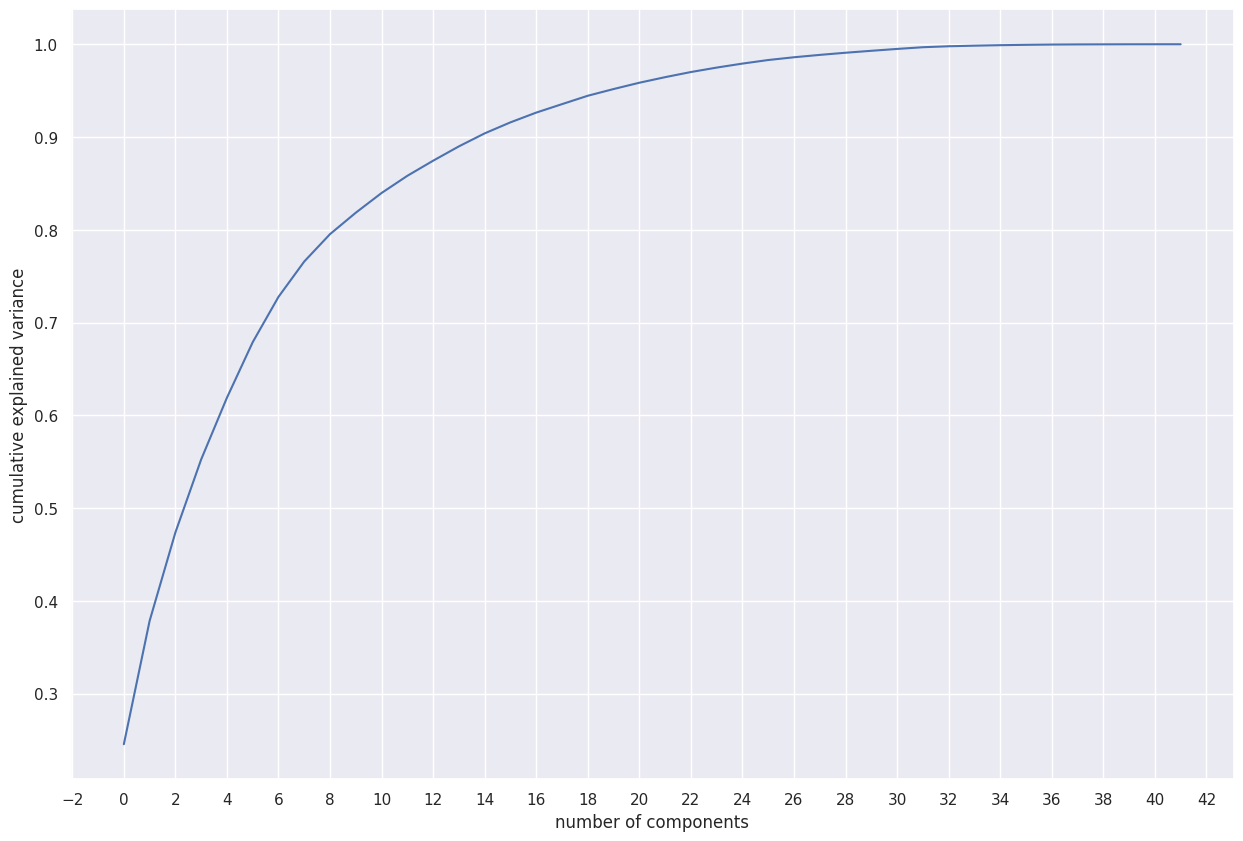

In [102]:
plt.plot(np.cumsum(pcafit.explained_variance_ratio_))
plt.locator_params(axis="x", nbins=len(pcafit.explained_variance_))
plt.xlabel('number of components')
plt.ylabel('cumulative explained variance');

As you can see from the above graph, 28 components describe almost 98% of variance in features

In [103]:
df_pca = sklearn_pca.fit_transform(df)
df_pca = pd.DataFrame(df_pca, columns=['pca0','pca1','pca2','pca3','pca4','pca5',
                                       'pca6','pca7','pca8','pca9','pca10','pca11',
                                       'pca12','pca13','pca14','pca15','pca16',
                                       'pca17','pca18','pca19','pca20','pca21','pca22',
                                       'pca23','pca24','pca25','pca26','pca27','pca28',
                                       'pca29','pca30','pca31','pca32','pca33',
                                       'pca34','pca35','pca36','pca37','pca38','pca39',
                                       'pca40','pca41'])

df_pca.head()

,pca0,pca1,pca2,pca3,pca4,pca5,pca6,pca7,pca8,pca9,pca10,pca11,pca12,pca13,pca14,pca15,pca16,pca17,pca18,pca19,pca20,pca21,pca22,pca23,pca24,pca25,pca26,pca27,pca28,pca29,pca30,pca31,pca32,pca33,pca34,pca35,pca36,pca37,pca38,pca39,pca40,pca41
0,-0.378572,0.330011,-0.146753,-0.802950,-0.190493,0.109574,0.189400,-0.216150,0.077683,-0.368114,0.273116,0.011357,0.145929,-0.067746,-0.681671,-0.108533,-0.019020,0.487650,0.479748,0.053924,0.093563,0.021257,-0.047042,0.017173,-0.113375,0.050235,0.084354,0.131126,0.191337,0.040485,-0.332542,0.893501,-0.073889,-0.097062,-0.006497,0.051611,-0.021150,0.001141,-0.004877,0.001629,0.001790,0.002765
1,-0.419449,0.387941,-0.101049,-0.890508,-0.572217,0.097246,-0.209294,0.548729,0.234791,-0.209456,0.142962,0.020526,0.193739,-0.035543,-0.592107,-0.104505,-0.061232,0.420055,0.556685,-0.048412,0.066635,0.037766,-0.010612,-0.037565,-0.149919,0.024264,-0.099037,0.055678,-0.002444,0.012525,0.018873,-0.003174,0.091770,-0.024939,0.004026,-0.013526,0.008594,-0.000296,-0.007243,0.000165,-0.001230,-0.002030
2,-0.160744,-0.484914,0.088655,-0.888479,0.789049,0.562101,-0.181209,0.152250,0.229561,-0.338420,0.189975,-0.078083,0.208598,0.177072,-0.636221,-0.099281,0.023427,0.289360,0.405831,-0.162618,0.216472,-0.038896,0.074980,0.006816,-0.183696,0.067466,-0.091625,0.036957,-0.015495,0.028420,0.097342,0.026951,0.040014,-0.045329,0.003805,-0.019202,0.008046,0.002222,-0.007468,0.000206,-0.000013,0.001820
3,-0.151133,-0.445583,0.036608,-0.900280,0.781132,0.557322,-0.167837,0.131936,0.222694,-0.337274,0.200325,-0.093461,0.193936,0.186686,-0.643766,-0.092623,0.006631,0.289490,0.390175,-0.193534,0.253891,-0.052251,0.088000,0.019656,-0.187770,0.068083,-0.092071,0.038440,-0.020413,0.024242,0.123725,0.042931,0.043067,-0.035319,-0.001771,-0.009982,0.002747,0.003083,-0.007271,0.000765,0.000013,0.002713
4,-0.403810,0.710319,0.442897,-0.263868,0.746503,0.625652,-0.108483,0.067395,0.302540,-0.296022,0.217749,-0.032364,0.129378,0.135461,-0.691891,-0.088616,0.009545,0.307109,0.411268,-0.170520,0.201204,-0.059333,0.033727,0.004168,-0.151004,0.068844,-0.096599,0.044956,-0.004065,0.022069,0.079570,0.032467,0.053490,-0.056168,0.003530,-0.013127,0.005646,0.001004,-0.007382,-0.000761,-0.000181,-0.000535


## 6.6 Multiple Linear Regression - After PCA<a id="mod_pca"></a>

In [89]:
df_pca = sm.add_constant(df_pca)

X = df_pca[['const','pca0','pca1','pca2','pca3','pca4','pca5','pca6','pca7','pca8','pca9','pca10','pca11','pca12','pca13','pca14','pca15','pca16','pca17','pca18','pca19','pca20','pca21','pca22','pca23','pca24','pca25','pca26','pca27','pca28','pca29','pca30','pca31','pca32','pca33']]

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

MLR_model_pca = sm.OLS(y_train, X_train).fit()
MLR_model_pca.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          CO2_Emissions   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.992
Method:                 Least Squares   F-statistic:                 1.285e+04
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:28:56   Log-Likelihood:                -10629.
No. Observations:                3697   AIC:                         2.133e+04
Df Residuals:                    3662   BIC:                         2.155e+04
Df Model:                          34                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        242.8084      0.071   3420.544      0.000     242.669     242.948
pca0         -11.8365      0.090   -131.451      0.000     -12.013     -11.660
pca1         -47.4501      0.120   -394.066      0.000     -47.686     -47.214
pca2          64.4047      0.145    444.572      0.000      64.121      64.689
pca3          13.0462      0.158     82.355      0.000      12.736      13.357
pca4           6.7918      0.172     39.440      0.000       6.454       7.129
pca5           0.6352      0.181      3.500      0.000       0.279       0.991
pca6         -11.1286      0.200    -55.508      0.000     -11.522     -10.736
pca7          27.4556      0.226    121.271      0.000      27.012      27.899
pca8          -3.7229      0.258    -14.431      0.000      -4.229      -3.217
pca9          13.2466      0.293     45.229      0.000      12.672      13.821
pca10          7.9782      0.303     26.364      0.000       7.385       8.571
pca11          4.9264      0.327     15.063      0.000       4.285       5.568
pca12          4.6794      0.348     13.438      0.000       3.997       5.362
pca13         29.1435      0.361     80.817      0.000      28.436      29.851
pca14         -5.2732      0.378    -13.940      0.000      -6.015      -4.531
pca15        -15.9522      0.397    -40.143      0.000     -16.731     -15.173
pca16         18.5528      0.430     43.136      0.000      17.710      19.396
pca17         -5.6703      0.465    -12.188      0.000      -6.582      -4.758
pca18         11.9213      0.461     25.852      0.000      11.017      12.825
pca19         21.8115      0.518     42.133      0.000      20.797      22.826
pca20        -35.6048      0.536    -66.377      0.000     -36.656     -34.553
pca21          4.9575      0.569      8.709      0.000       3.841       6.074
pca22          5.8563      0.585     10.019      0.000       4.710       7.002
pca23          2.5417      0.648      3.921      0.000       1.271       3.813
pca24         -5.8168      0.668     -8.705      0.000      -7.127      -4.507
pca25          3.0145      0.703      4.287      0.000       1.636       4.393
pca26         -6.6339      0.820     -8.090      0.000      -8.241      -5.026
pca27          5.1417      0.889      5.782      0.000       3.398       6.885
pca28         37.6697      0.943     39.926      0.000      35.820      39.520
pca29         27.0491      1.044     25.920      0.000      25.003      29.095
pca30       -121.6564      1.004   -121.132      0.000    -123.626    -119.687
pca31        -66.1677      1.047    -63.182      0.000     -68.221     -64.114
pca32         -6.8155      1.380     -4.940      0.000      -9.520      -4.111
pca33         40.2886      1.742     23.122      0.000      36.872      43.705
==============================================================================
Om

1. 99.3% of the variation is dependent on variable CO2_Emissions.
2. The Durbin-Watson test statistic is 2.053 and indicates that there is no auto-correlation
3. The Condition Number is 23.4 which suggests that there is no mutli-collinearity

## 6.7 Feature Selection<a id="fea_sel"></a>

### 6.7.1 Forward Selection<a id="for_sel"></a>

In [104]:
linreg = LinearRegression()
linreg_forward = sfs(estimator=linreg, k_features ='best', forward=True,
                     verbose=0, scoring='r2')

sfs_forward = linreg_forward.fit(X_train, y_train)

In [105]:
print('Features selected using forward selection are: ')
print(sfs_forward.k_feature_names_)

print('\nR-Squared: ', sfs_forward.k_score_)

Features selected using forward selection are: 
('pca0', 'pca1', 'pca2', 'pca3', 'pca4', 'pca5', 'pca6', 'pca7', 'pca8', 'pca9', 'pca10', 'pca11', 'pca12', 'pca13', 'pca14', 'pca15', 'pca16', 'pca17', 'pca18', 'pca19', 'pca20', 'pca21', 'pca23', 'pca24', 'pca25', 'pca26', 'pca27', 'pca28', 'pca29', 'pca30', 'pca31', 'pca32', 'pca33')

R-Squared:  0.9911102828634244


### 6.7.2 Backward Elimination<a id="bac_eli"></a>

In [106]:
linreg = LinearRegression()
linreg_backward = sfs(estimator = linreg, k_features ='best', forward = False,
                     verbose = 0, scoring = 'r2')

sfs_backward = linreg_backward.fit(X_train, y_train)

In [107]:
print('Features selected using backward elimination are: ')
print(sfs_backward.k_feature_names_)

print('\nR-Squared: ', sfs_backward.k_score_)

Features selected using backward elimination are: 
('const', 'pca0', 'pca1', 'pca2', 'pca3', 'pca4', 'pca5', 'pca6', 'pca7', 'pca8', 'pca9', 'pca10', 'pca11', 'pca12', 'pca13', 'pca14', 'pca15', 'pca16', 'pca17', 'pca18', 'pca19', 'pca20', 'pca21', 'pca23', 'pca24', 'pca25', 'pca26', 'pca27', 'pca28', 'pca29', 'pca30', 'pca31', 'pca32', 'pca33')

R-Squared:  0.9911102828634244


Obtained similar results as that of Forward Selection where all features except and pca_22 have been retained for the betterment of the model

## 6.8 Multiple Linear Regression - Full Model - After Feature Selection<a id="mod_fea_sel"></a>

In [112]:
selected_features = list(sfs_backward.k_feature_names_)
X = X[selected_features]

In [113]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

MLR_full_model = sm.OLS(y_train, X_train).fit()
MLR_full_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          CO2_Emissions   R-squared:                       0.991
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                 1.289e+04
Date:                Thu, 09 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:32:28   Log-Likelihood:                -10679.
No. Observations:                3697   AIC:                         2.143e+04
Df Residuals:                    3663   BIC:                         2.164e+04
Df Model:                          33                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        242.8187      0.072   3375.560      0.000     242.678     242.960
pca0         -11.8295      0.091   -129.631      0.000     -12.008     -11.651
pca1         -47.4370      0.122   -388.742      0.000     -47.676     -47.198
pca2          64.3955      0.147    438.607      0.000      64.108      64.683
pca3          13.0753      0.161     81.455      0.000      12.761      13.390
pca4           6.8003      0.175     38.965      0.000       6.458       7.143
pca5           0.6209      0.184      3.377      0.001       0.260       0.981
pca6         -11.1343      0.203    -54.798      0.000     -11.533     -10.736
pca7          27.4371      0.229    119.582      0.000      26.987      27.887
pca8          -3.7337      0.261    -14.281      0.000      -4.246      -3.221
pca9          13.2487      0.297     44.634      0.000      12.667      13.831
pca10          7.9853      0.307     26.037      0.000       7.384       8.587
pca11          4.9579      0.331     14.959      0.000       4.308       5.608
pca12          4.6805      0.353     13.263      0.000       3.989       5.372
pca13         29.1078      0.365     79.648      0.000      28.391      29.824
pca14         -5.2747      0.383    -13.758      0.000      -6.026      -4.523
pca15        -15.9518      0.403    -39.609      0.000     -16.741     -15.162
pca16         18.5406      0.436     42.535      0.000      17.686      19.395
pca17         -5.6301      0.471    -11.941      0.000      -6.555      -4.706
pca18         11.8858      0.467     25.433      0.000      10.970      12.802
pca19         21.8839      0.525     41.715      0.000      20.855      22.912
pca20        -35.6167      0.544    -65.517      0.000     -36.683     -34.551
pca21          4.8034      0.577      8.329      0.000       3.673       5.934
pca23          2.5688      0.657      3.910      0.000       1.281       3.857
pca24         -5.8403      0.677     -8.624      0.000      -7.168      -4.513
pca25          3.0180      0.713      4.235      0.000       1.621       4.415
pca26         -6.6144      0.831     -7.960      0.000      -8.244      -4.985
pca27          5.2134      0.901      5.785      0.000       3.447       6.980
pca28         37.7487      0.956     39.480      0.000      35.874      39.623
pca29         27.1014      1.058     25.625      0.000      25.028      29.175
pca30       -121.6419      1.018   -119.507      0.000    -123.637    -119.646
pca31        -66.2064      1.061    -62.379      0.000     -68.287     -64.125
pca32         -6.9992      1.398     -5.006      0.000      -9.740      -4.258
pca33         40.2207      1.766     22.776      0.000      36.758      43.683
==============================================================================
Omnibus:                     4045.977   Durbin-Watson:                   1.999
Pr

 1. 99.3% of the variation is dependent on variable CO2_Emissions.
 2. The Durbin-Watson test statistic is 2.051 and indicates that there is no auto-correlation
 3. The Condition Number is 23.4 which suggests that there is no mutli-collinearity

## 6.9 Assumptions After Multiple Linear Regression Model<a id="ass_aft"></a>

### 6.9.1 Assumption #1: Linear Relationship Between Dependent and Independent Variable<a id="lr_dep_ind"></a>

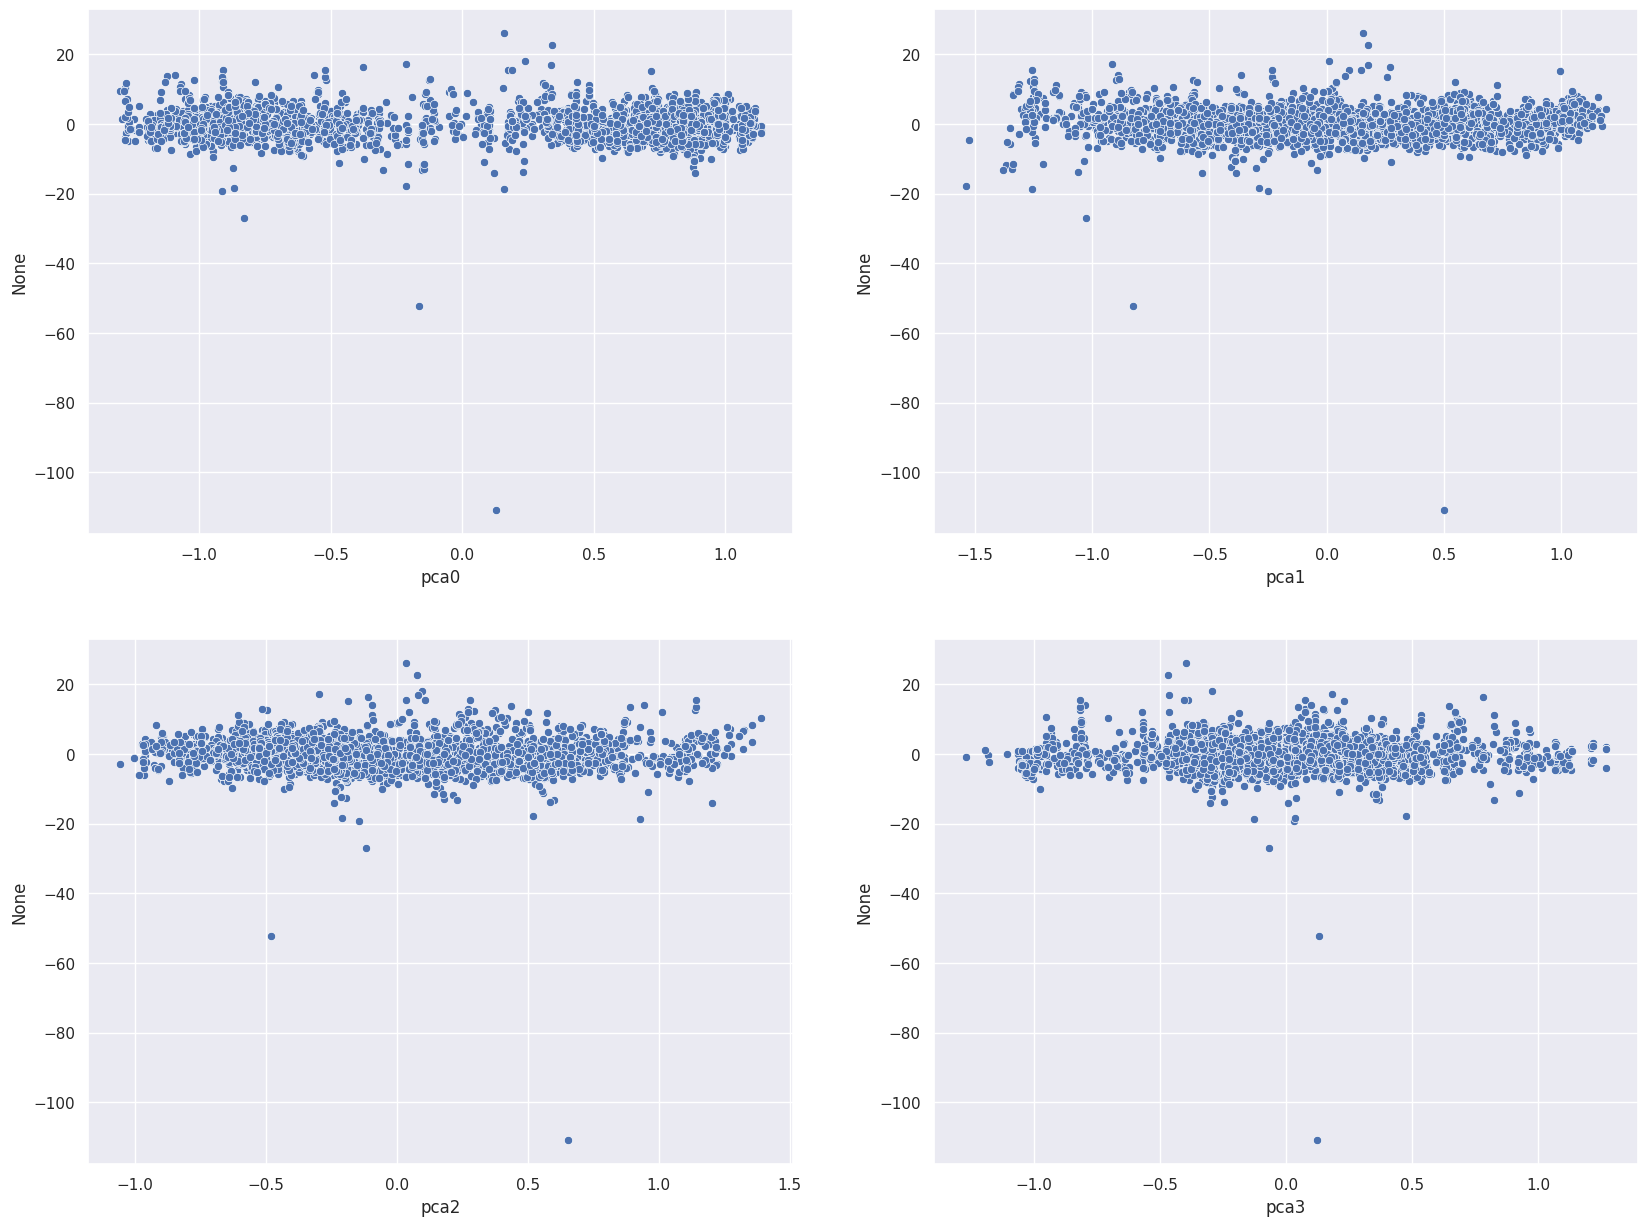

In [117]:
fig, ax = plt.subplots(nrows = 2, ncols= 2, figsize=(20, 15))

# 'ax' assigs axes object to draw the plot onto
for variable, subplot in zip(X_train.columns[1:5], ax.flatten()):
    sns.scatterplot(x=X_train[variable], y=MLR_full_model.resid , ax=subplot)

plt.show()

 The above plots show no specific pattern, implies that there is a linearity present in the data

### 6.9.2 Assumption #2: Checking for Autocorrelation<a id="che_aut_cor"></a>

From the above summary [Section 6.8](#mod_fea_sel), we can observe that the value obtained from the `Durbin-Watson` test statistic is close to **2** (= 2.012). Thus, we conclude that there is no autocorrelation.

### 6.9.3 Assumption #3: Checking for Heteroskedasticity<a id="che_het"></a>

Breusch-Pagan is one of the tests for detecting heteroskedasticity in the residuals.<br>
The test hypothesis for the Breusch-Pagan test is given as:
<p style='text-indent:25em'> <strong> H<sub>o</sub>:  There is homoscedasticity present in the data </strong> </p>
<p style='text-indent:25em'> <strong> H<sub>1</sub>:  There is a heteroscedasticity present in the data </strong> </p>

In [118]:
name = ['f-value','p-value']
test = sms.het_breuschpagan(MLR_full_model.resid, MLR_full_model.model.exog)
lzip(name, test[2:])

[('f-value', np.float64(2.9067603765422376)),
 ('p-value', np.float64(6.267004364598133e-08))]

We observe that the p-value is less than 0.05; thus, we conclude that there is heteroskedasticity present in the data.

### 6.9.4 Assumption #4: Tests for Normality<a id="tes_nor"></a>

#### 6.9.4.1 Q-Q Plot<a id="qq_plt"></a>

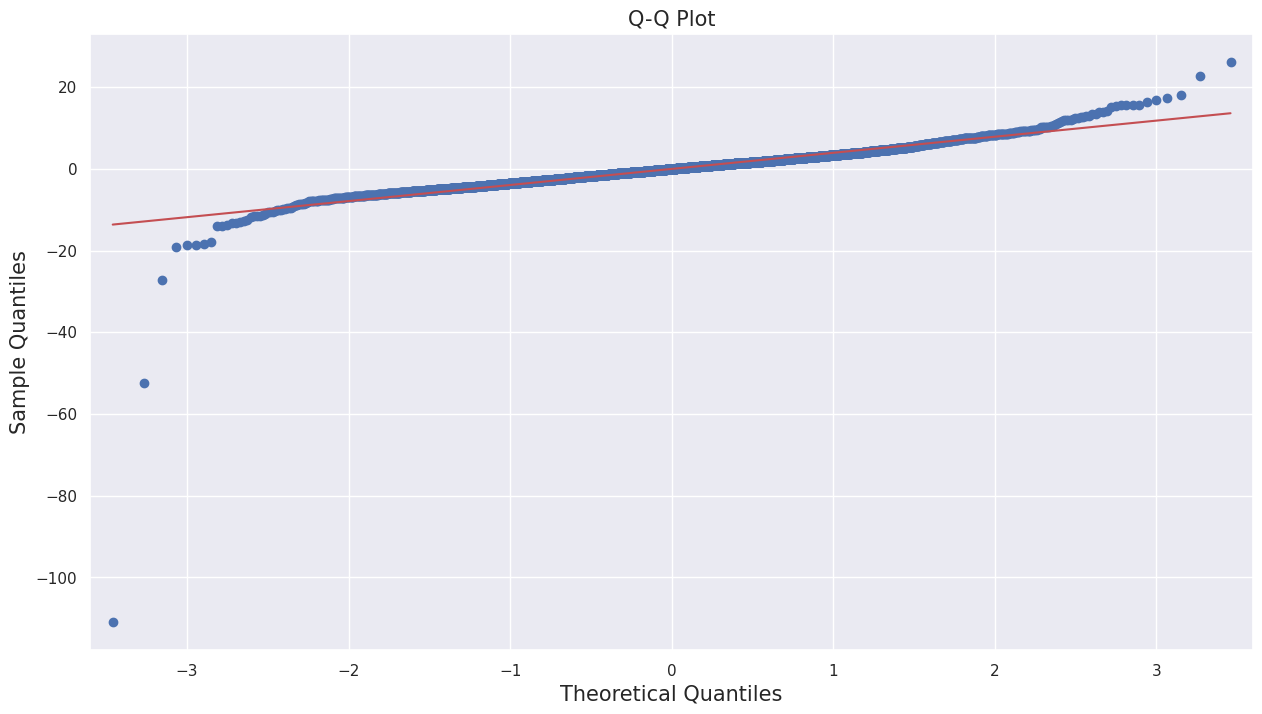

In [119]:
plt.rcParams['figure.figsize'] = [15,8]

qqplot(MLR_full_model.resid, line = 'r')

plt.title('Q-Q Plot', fontsize = 15)
plt.xlabel('Theoretical Quantiles', fontsize = 15)
plt.ylabel('Sample Quantiles', fontsize = 15)

plt.show()

 The diagonal line (red line) is the regression line and the blue points are the cumulative distribution of the residuals. As some of the points are not close to the diagonal line, we conclude that the residuals do not follow a `normal distribution.`

#### 6.9.4.2 Shapiro Wilk Test<a id="sha_wil_tes"></a>

The Shapiro Wilk test is used to check the normality of the residuals. The test hypothesis is given as:<br>

<p style='text-indent:25em'> <strong> H<sub>o</sub>:  Residuals are normally distributed </strong> </p>
<p style='text-indent:25em'> <strong> H<sub>1</sub>:  Residuals are not normally distributed </strong> </p>

In [120]:
stat, p_value = shapiro(MLR_full_model.resid)
print('Test statistic:', stat)
print('P-Value:', p_value)

Test statistic: 0.822183774178886
P-Value: 1.7405137633755054e-53


From the above test we can see that the p-value is 1.365e-38 (less than 0.05), thus we can say that the residuals are not normally distributed.



# 7. Model Evaluation<a id="mod_eva"></a>

## 7.1 Measures of Variation<a id="mea_var"></a>

In [121]:
y_train_pred = MLR_full_model.predict(X_train)
y_train_pred.head()

,0
2457,225.470133
4606,225.045862
4369,162.033333
1804,179.299217
3845,300.942821


In [122]:
ssr = np.sum((y_train_pred - y_train.mean())**2)
sse = np.sum((y_train - y_train_pred)**2)
sst = np.sum((y_train - y_train.mean())**2)


print('Sum of Squared Regression:',ssr)
print('Sum of Squared Error:',sse)
print('Sum of Sqaured Total:',sst)
print('Sum of SSR and SSE is:',ssr+sse)

Sum of Squared Regression: 8114718.48362471
Sum of Squared Error: 69894.78821733895
Sum of Sqaured Total: 8184613.2718420345
Sum of SSR and SSE is: 8184613.2718420485


In [123]:
r_sq =MLR_full_model.rsquared

# print the R-squared value
print('R Squared is:',r_sq)

R Squared is: 0.991460221039667


In [124]:
see = np.sqrt(sse/(len(X_train) - 2))
print("The standard error of estimate:",see)

The standard error of estimate: 4.3492580431226235


## 7.2 Inferences about Intercept and Slope<a id="inf_int_slo"></a>

In [125]:
t_intercept =MLR_full_model.params[0] / MLR_full_model.bse[0]
print('t intercept:',t_intercept)

t intercept: 3375.5604404687992


In [126]:
t_coeff1 =MLR_full_model.params[1] / MLR_full_model.bse[1]
print('t coeff:',t_coeff1)

t coeff: -129.63068453979398


degrees of freedom = n - 1 = 4070 - 1 = 4069

In [127]:
pval = stats.t.sf(np.abs(t_intercept), 4069)*2
print('p val for intercept:',pval)

p val for intercept: 0.0


## 7.3 Confidence Interval for Intercept and Slope<a id="con_int_slo"></a>

t_table_value = 1.9622

In [128]:
CI_inter_min, CI_inter_max = MLR_full_model.params[0] - (1.9622*MLR_full_model.bse[0]), MLR_full_model.params[0] + (1.9622*MLR_full_model.bse[0])
print('CI for intercept:', [CI_inter_min , CI_inter_max])

CI for intercept: [np.float64(242.6775510469843), np.float64(242.9598501571464)]


In [129]:
CI_coeff1_min, CI_coeff1_max = MLR_full_model.params[1] - (1.9622*MLR_full_model.bse[1]), MLR_full_model.params[1] + (1.9622*MLR_full_model.bse[1])
print('CI for coeff1:', [CI_coeff1_min, CI_coeff1_max])

CI for coeff1: [np.float64(-12.00857203116087), np.float64(-11.650449019845343)]


## 7.4 Compare Regression Results<a id="com_reg_res"></a>

In [130]:
r_sq_mlr = MLR_full_model.rsquared
print('r square in regression model:',r_sq_mlr)

r square in regression model: 0.991460221039667


The value of R-squared is 0.993. Thus, we conclude that the 99.3% variation in the CO2_Emissions is explained by the model.

In [131]:
adj_r_sq = MLR_full_model.rsquared_adj
print('Adjusted r square for regression model:',adj_r_sq)

Adjusted r square for regression model: 0.9913832860940784


Overall F-Test & p-value of the Model

compute f_value using the below formula


f_value = (r_sq / k-1)/((1- r_sq)/n-k)

k = number of beta coefficients
n = number of observations

In [132]:
k = len(X_train.columns)
n = len(X_train)

f_value = (r_sq_mlr / (k - 1))/((1-r_sq_mlr)/(n - k))
print('f value for regression model:',f_value)

f value for regression model: 12886.994504962217


degrees of freedom
dfn = k-1 = 32-1 = 31
dfd = n-k = 4396-32 = 4364

In [133]:
p_val = stats.f.sf(f_value, dfn = 31, dfd = 4364)
print('p value for regression model:',p_val)

p value for regression model: 0.0


As, the p-value is 0 which is less than 0.05, we accept the alternate hypothesis; i.e. the model is significant.

# 8. Model Performance<a id="mod_per"></a>

In [134]:
train_pred = MLR_full_model.predict(X_train)
test_pred = MLR_full_model.predict(X_test)

## 8.1 Mean Squared Error (MSE)<a id="mse"></a>

In [135]:
mse_train = round(mean_squared_error(y_train, train_pred),4)
mse_test = round(mean_squared_error(y_test, test_pred),4)

print("Mean Squared Error (MSE) on training set: ", mse_train)
print("Mean Squared Error (MSE) on test set: ", mse_test)

Mean Squared Error (MSE) on training set:  18.9058
Mean Squared Error (MSE) on test set:  17.1681


## 8.2 Root Mean Squared Error (RMSE)<a id="rmse"></a>

In [136]:
mse_train = mean_squared_error(y_train, train_pred)
rmse_train = round(np.sqrt(mse_train), 4)

mse_test = mean_squared_error(y_test, test_pred)
rmse_test = round(np.sqrt(mse_test), 4)

print("Root Mean Squared Error (RMSE) on training set: ", rmse_train)
print("Root Mean Squared Error (RMSE) on test set: ", rmse_test)

Root Mean Squared Error (RMSE) on training set:  4.3481
Root Mean Squared Error (RMSE) on test set:  4.1434


## 8.3 Mean Absolute Error (MAE)<a id="mae"></a>

In [137]:
mae_train = round(mean_absolute_error(y_train, train_pred),4)
mae_test = round(mean_absolute_error(y_test, test_pred),4)


print("Mean Absolute Error (MAE) on training set: ", mae_train)
print("Mean Absolute Error (MAE) on test set: ", mae_test)

Mean Absolute Error (MAE) on training set:  2.9358
Mean Absolute Error (MAE) on test set:  3.0632


## 8.4 Mean Absolute Percentage Error (MAPE)<a id="mape"></a>

In [138]:
def mape(actual, predicted):
    return (np.mean(np.abs((actual - predicted) / actual)) * 100)

In [139]:
mape_train = round(mape(y_train, train_pred),4)
mape_test = round(mape(y_test, test_pred),4)

print("Mean Absolute Percentage Error (MAPE) on training set: ", mape_train)
print("Mean Absolute Percentage Error (MAPE) on test set: ", mape_test)

Mean Absolute Percentage Error (MAPE) on training set:  1.2523
Mean Absolute Percentage Error (MAPE) on test set:  1.2803


## 8.5 Result Table<a id="res_tab"></a>

In [142]:
cols = ['Model_Name', 'R-squared', 'Adj. R-squared', 'MSE', 'RMSE', 'MAE', 'MAPE']

result_table = pd.DataFrame(columns = cols)

MLR_full_model_metrics = pd.Series({
    'Model_Name': "MLR Full Model",
    'R-squared': MLR_full_model.rsquared,
    'Adj. R-squared': MLR_full_model.rsquared_adj,
    'MSE': mean_squared_error(y_test, test_pred),
    'RMSE': rmse(y_test, test_pred),
    'MAE': mean_absolute_error(y_test, test_pred),
    'MAPE': mape(y_test, test_pred)
})

result_table = pd.concat([result_table, MLR_full_model_metrics.to_frame().T], ignore_index = True)

result_table

,Model_Name,R-squared,Adj. R-squared,MSE,RMSE,MAE,MAPE
0,MLR Full Model,0.991460,0.991383,17.168115,4.143442,3.063213,1.280273


# 9. Model Optimization<a id="mod_opt"></a>

## 9.1 BIAS <a id="bias"></a>

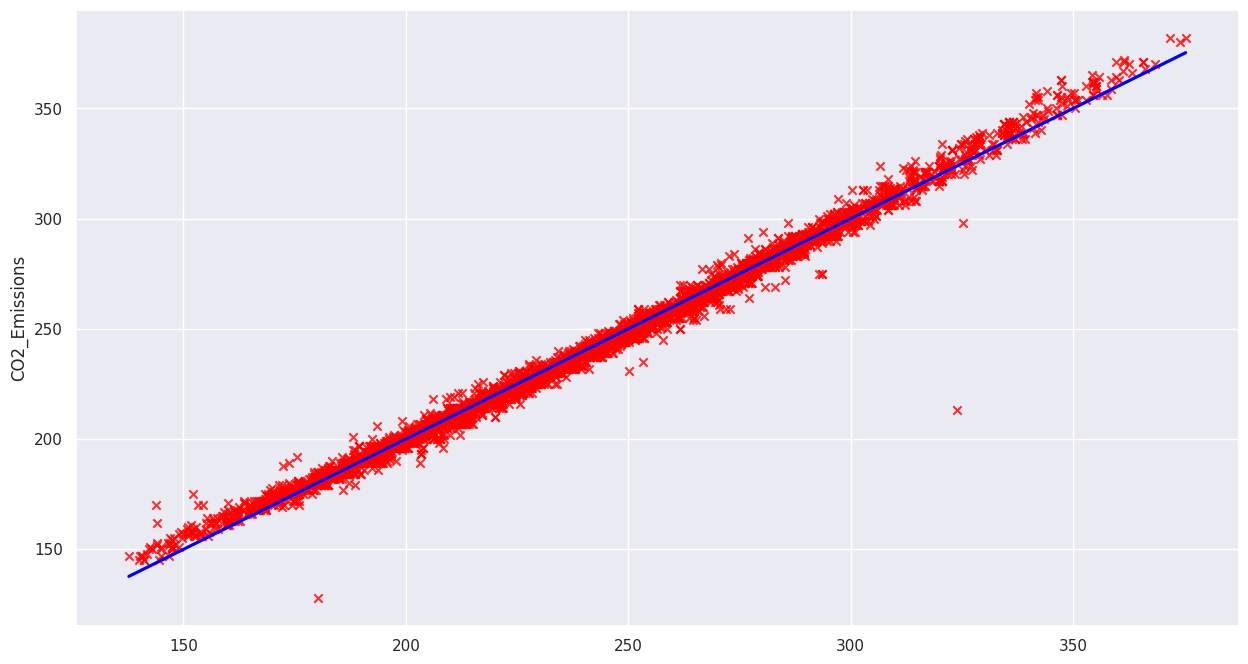

In [143]:
sns.regplot(y = y_train,x = train_pred,color='red',line_kws={'color':'blue'},marker='x')
plt.show()

## 9.2 VARIANCE<a id="var"></a>

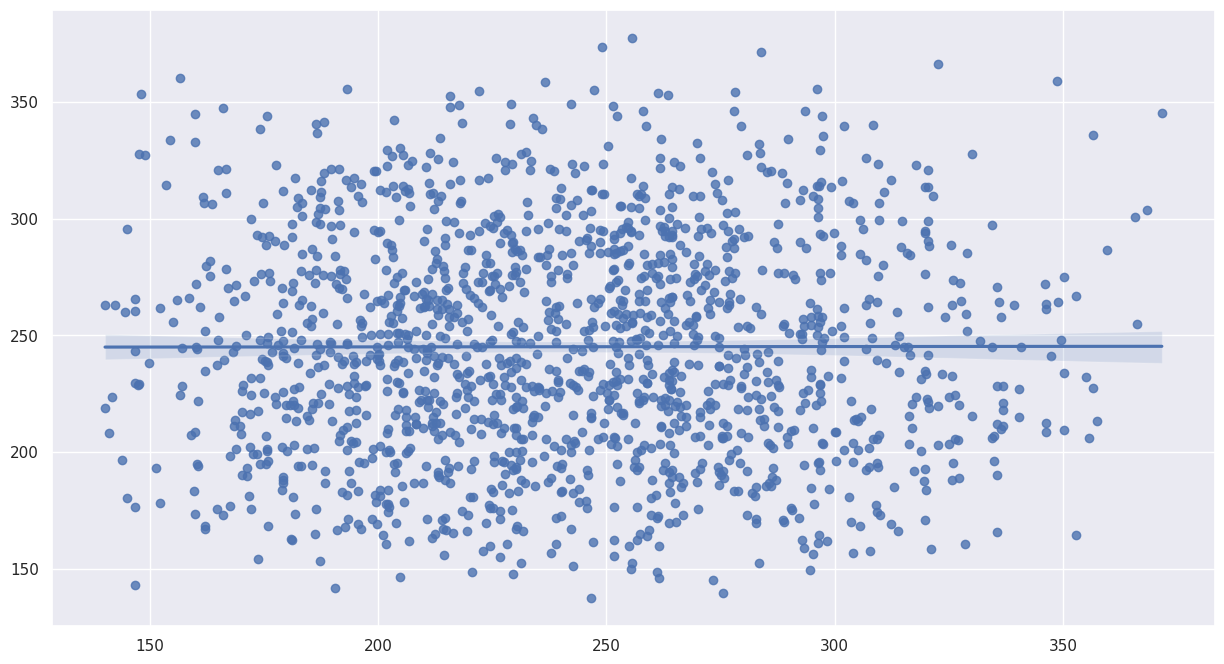

In [148]:
a = np.random.randint(0, len(train_pred), len(test_pred))
train_pred1 = list(train_pred)
TrainPred2 = []

for i in a:
    TrainPred2.append(train_pred1[i])

sns.regplot(y = test_pred,x = TrainPred2)
plt.show()

The bias is low and variance is high, hence we can assume that the model is a complex one. We will have to employ optimization techniques to reduce the complexity and RMSE.

# 9.3. MODEL VALIDATION<a id="mod_val"></a>

## 9.3.1 Cross Validation<a id="cro_val"></a>

In [149]:
kf = KFold(n_splits = 10)

def Get_score(model, X_train_k, X_test_k, y_train_k, y_test_k):
    model.fit(X_train_k, y_train_k)
    return model.score(X_test_k, y_test_k)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 10, test_size = 0.3)

In [150]:
scores = []

for train_index, test_index in kf.split(X_train):
    X_train_k, X_test_k, y_train_k, y_test_k = X_train.iloc[train_index], X_train.iloc[test_index], \
                                               y_train.iloc[train_index], y_train.iloc[test_index]

    scores.append(Get_score(LinearRegression(), X_train_k, X_test_k, y_train_k, y_test_k))


print('All scores: ', scores)
print("\nMinimum score obtained: ", round(min(scores), 4))
print("Maximum score obtained: ", round(max(scores), 4))
print("Average score obtained: ", round(np.mean(scores), 4))

All scores:  [0.9942385962675496, 0.9936274851198937, 0.9944617035173363, 0.9926089955925738, 0.9930187025197285, 0.9871442377688788, 0.9766676601040388, 0.9925016769578269, 0.9939188581260252, 0.9933515914010846]

Minimum score obtained:  0.9767
Maximum score obtained:  0.9945
Average score obtained:  0.9912


In [151]:
scores = cross_val_score(estimator = LinearRegression(),
                         X = X_train,
                         y = y_train,
                         cv = 10,
                         scoring = 'r2')

print('All scores: ', scores)
print("\nMinimum score obtained: ", round(min(scores), 4))
print("Maximum score obtained: ", round(max(scores), 4))
print("Average score obtained: ", round(np.mean(scores), 4))

All scores:  [0.9942386  0.99362749 0.9944617  0.992609   0.9930187  0.98714424
 0.97666766 0.99250168 0.99391886 0.99335159]

Minimum score obtained:  0.9767
Maximum score obtained:  0.9945
Average score obtained:  0.9912


**The R2 value is similar to the one obtained in the MLR model. There are no significant changes.**

## 9.3.2 Leave Out One Cross Validation(LOOCV)<a id="loocv"></a>

In [152]:
def Get_score(model, X_train_k, X_test_k, y_train_k, y_test_k):
    model.fit(X_train_k, y_train_k)
    return model.score(X_test_k, y_test_k)

In [153]:
loocv_rmse = []
loocv = LeaveOneOut()

for train_index, test_index in loocv.split(X_train):

    X_train_l, X_test_l, y_train_l, y_test_l = X_train.iloc[train_index], X_train.iloc[test_index], \
                                               y_train.iloc[train_index], y_train.iloc[test_index]

    linreg = LinearRegression()
    linreg.fit(X_train_l, y_train_l)

    mse = mean_squared_error(y_test_l, linreg.predict(X_test_l))
    rmse = np.sqrt(mse)
    loocv_rmse.append(rmse)

In [154]:
print("\nMinimum rmse obtained: ", round(min(loocv_rmse), 4))
print("Maximum rmse obtained: ", round(max(loocv_rmse), 4))
print("Average rmse obtained: ", round(np.mean(loocv_rmse), 4))


Minimum rmse obtained:  0.0009
Maximum rmse obtained:  113.1901
Average rmse obtained:  2.9657


# 9.4 GRADIENT DESCENT<a id="gra_des"></a>

Helper functions

In [162]:
def get_train_rmse(model):

    train_pred = model.predict(X_train)
    mse_train = mean_squared_error(y_train, train_pred)
    rmse_train = round(np.sqrt(mse_train), 4)
    return(rmse_train)

def get_test_rmse(model):

    test_pred = model.predict(X_test)
    mse_test = mean_squared_error(y_test, test_pred)
    rmse_test = round(np.sqrt(mse_test), 4)
    return(rmse_test)

def get_test_mape(model):

    test_pred = model.predict(X_test)
    mape_test = mape(y_test, test_pred)
    return(mape_test)

def plot_coefficients(model, algorithm_name):

    df_coeff = pd.DataFrame({'Variable': X.columns, 'Coefficient': model.coef_})
    sorted_coeff = df_coeff.sort_values('Coefficient', ascending = False)
    sns.barplot(x = "Coefficient", y = "Variable", data = sorted_coeff)
    plt.xlabel("Coefficients from {}".format(algorithm_name), fontsize = 15)
    plt.ylabel('Features', fontsize = 15)

def get_score(model):

    r_sq = model.score(X_train, y_train)
    n = X_train.shape[0]
    k = X_train.shape[1]
    r_sq_adj = 1 - ((1-r_sq)*(n-1)/(n-k-1))
    return ([r_sq, r_sq_adj])

In [163]:
sgd = SGDRegressor(random_state = 10)
linreg_with_SGD = sgd.fit(X_train, y_train)

print('RMSE on train set:', get_train_rmse(linreg_with_SGD))
print('RMSE on test set:', get_test_rmse(linreg_with_SGD))

RMSE on train set: 4.395
RMSE on test set: 4.2267


In [164]:
MLR_model = linreg.fit(X_train, y_train)

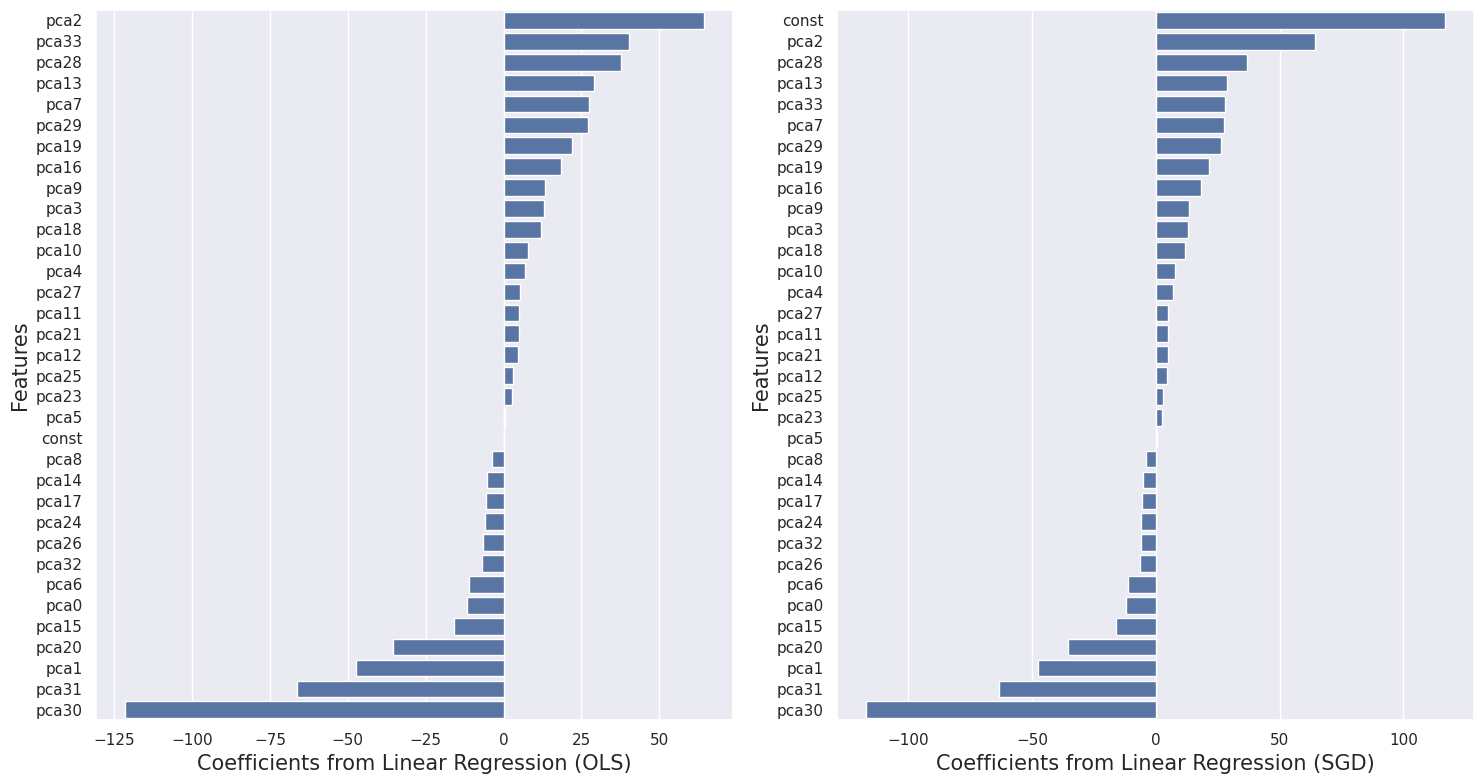

In [165]:
plt.subplot(1,2,1)
plot_coefficients(MLR_model, 'Linear Regression (OLS)')

plt.subplot(1,2,2)
plot_coefficients(linreg_with_SGD, 'Linear Regression (SGD)')

plt.tight_layout()

In [166]:
score_card = pd.DataFrame(columns=['Model_Name', 'Alpha (Wherever Required)', 'l1-ratio', 'R-Squared',
                                       'Adj. R-Squared', 'Train_RMSE','Test_RMSE', 'Test_MAPE'])

def update_score_card(algorithm_name, model, alpha = '-', l1_ratio = '-'):

    global score_card
    new_entry = pd.DataFrame([{
        'Model_Name': algorithm_name,
        'Alpha (Wherever Required)': alpha,
        'l1-ratio': l1_ratio,
        'Test_MAPE': get_test_mape(model),
        'Train_RMSE': get_train_rmse(model),
        'Test_RMSE': get_test_rmse(model),
        'R-Squared': get_score(model)[0],
        'Adj. R-Squared': get_score(model)[1]
    }])
    score_card = pd.concat([score_card, new_entry], ignore_index = True)

In [167]:
update_score_card(algorithm_name = 'Linear Regression (using SGD)', model = linreg_with_SGD)

score_card

,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Train_RMSE,Test_RMSE,Test_MAPE
0,Linear Regression (using SGD),-,-,0.991275,0.991194,4.395000,4.226700,1.296287


# 9.5  Regularization<a id="reg"></a>

## 9.5.1 Ridge Regression Model<a id="ridge"></a>

In [168]:
ridge = Ridge(alpha = 0.1, max_iter = 500)
ridge.fit(X_train, y_train)

update_score_card(algorithm_name='Ridge Regression (with alpha = 0.1)', model = ridge, alpha = 0.1)

print('RMSE on test set:', get_test_rmse(ridge))

RMSE on test set: 4.15


In [169]:
ridge = Ridge(alpha = 1, max_iter = 500)
ridge.fit(X_train, y_train)

update_score_card(algorithm_name='Ridge Regression (with alpha = 1)', model = ridge, alpha = 1)

print('RMSE on test set:', np.round(get_test_rmse(ridge),2))

RMSE on test set: 4.24


In [170]:
ridge = Ridge(alpha = 2, max_iter = 500)
ridge.fit(X_train, y_train)

update_score_card(algorithm_name='Ridge Regression (with alpha = 2)', model = ridge, alpha = 2)

print('RMSE on test set:', get_test_rmse(ridge))

RMSE on test set: 4.4001


In [171]:
ridge = Ridge(alpha = 0.5, max_iter = 500)
ridge.fit(X_train, y_train)

update_score_card(algorithm_name='Ridge Regression (with alpha = 0.5)', model = ridge, alpha = 0.5)

print('RMSE on test set:', get_test_rmse(ridge))

RMSE on test set: 4.1846


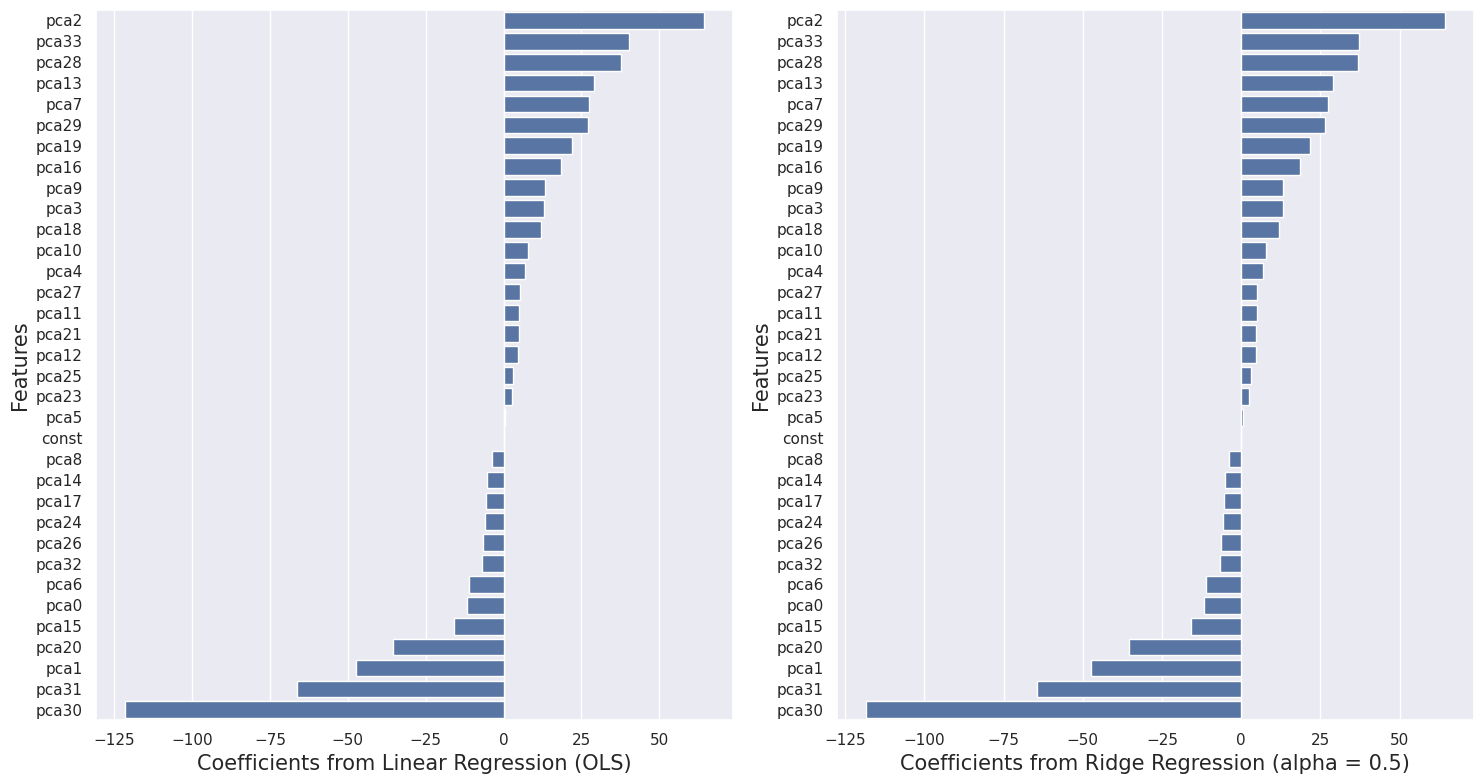

In [172]:
plt.subplot(1,2,1)
plot_coefficients(MLR_model, 'Linear Regression (OLS)')

plt.subplot(1,2,2)
plot_coefficients(ridge, 'Ridge Regression (alpha = 0.5)')

plt.tight_layout()

The coefficients obtained from ridge regression have similar values as compared to the coefficients obtained from linear regression using OLS.

## 9.5.2 Lasso Regression Model<a id="lasso"></a>

In [173]:
lasso = Lasso(alpha = 0.01, max_iter = 500)
lasso.fit(X_train, y_train)

print('RMSE on test set:', get_test_rmse(lasso))

RMSE on test set: 4.2039


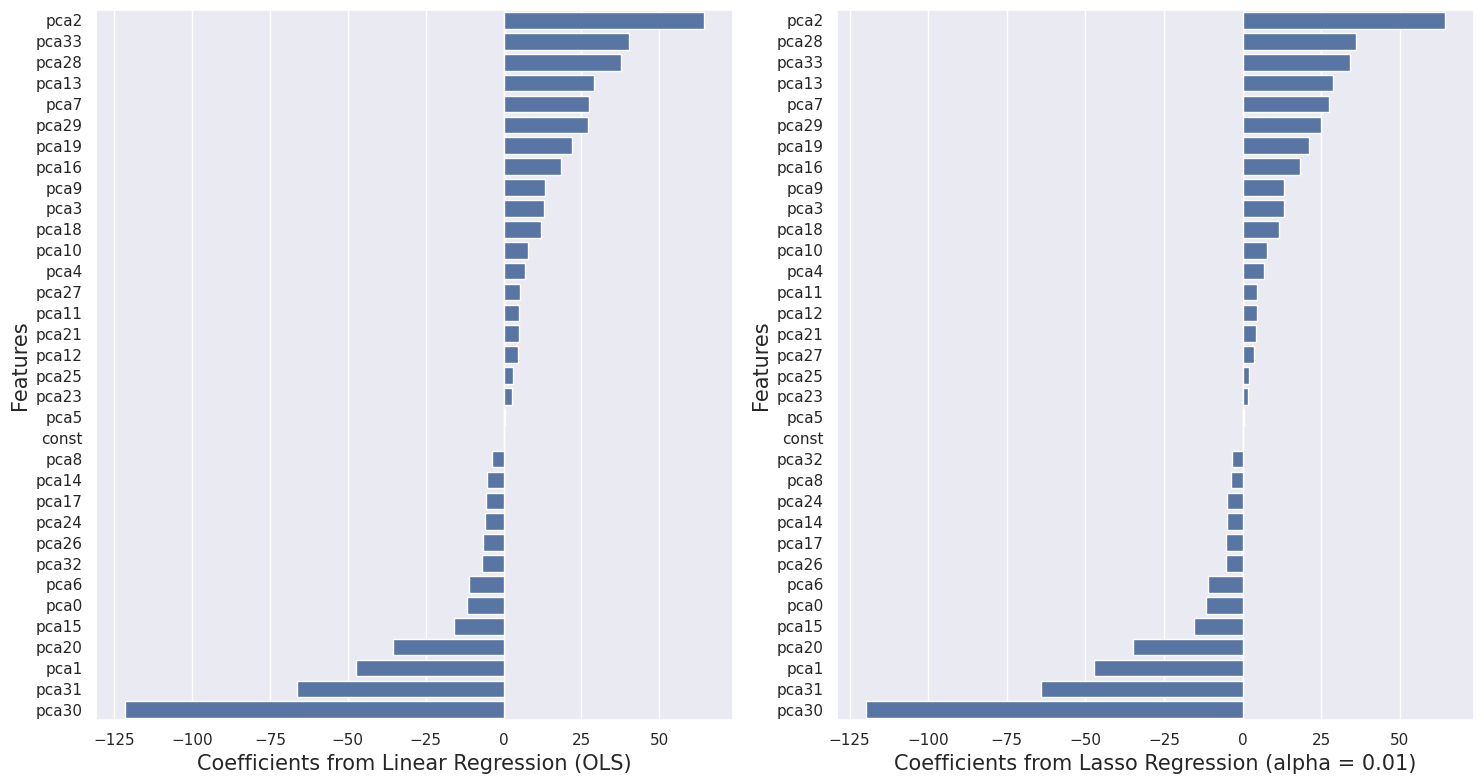

In [174]:
plt.subplot(1,2,1)
plot_coefficients(MLR_model, 'Linear Regression (OLS)')

plt.subplot(1,2,2)
plot_coefficients(lasso, 'Lasso Regression (alpha = 0.01)')

plt.tight_layout()

In [175]:
lasso = Lasso(alpha = 0.05, max_iter = 500)
lasso.fit(X_train, y_train)

print('RMSE on test set:', get_test_rmse(lasso))

RMSE on test set: 4.9534


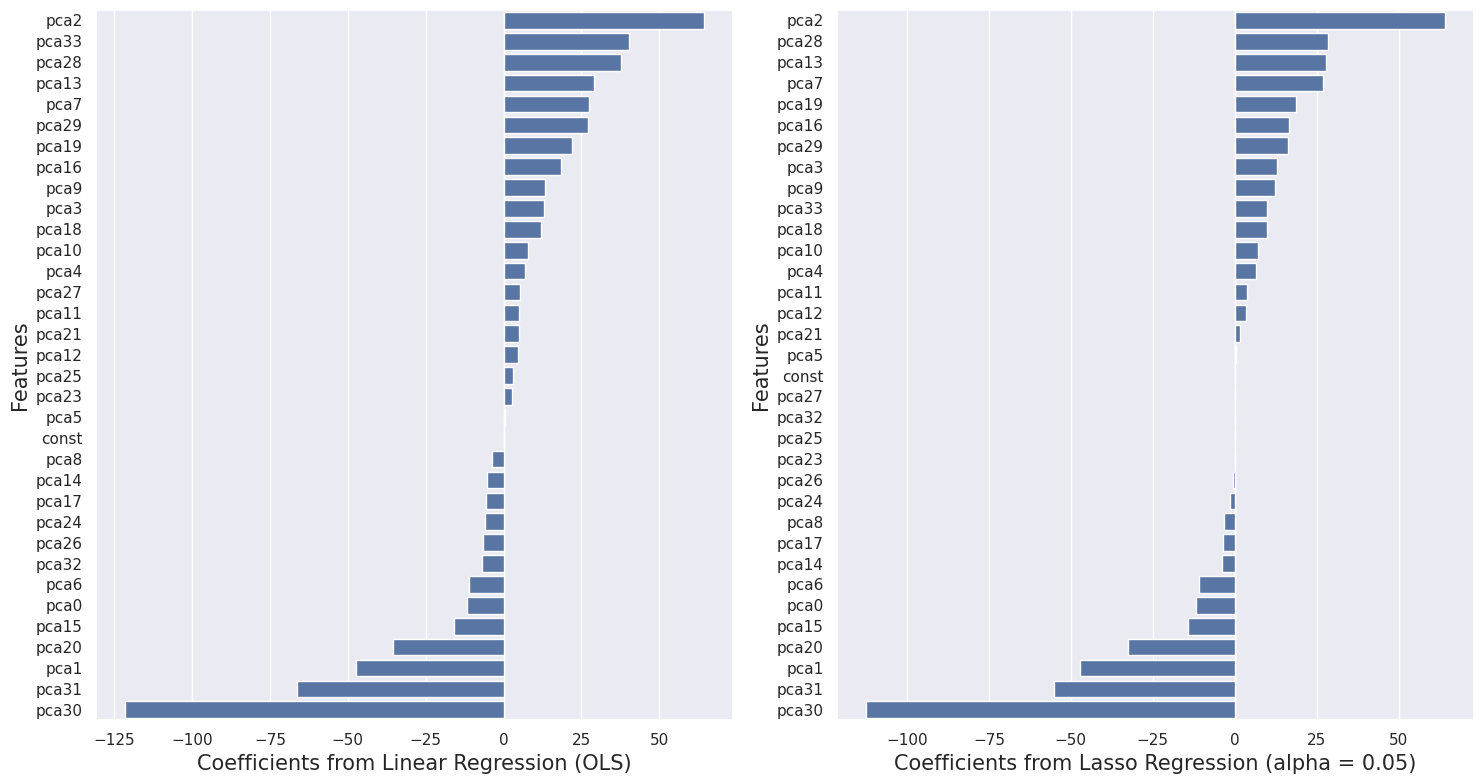

In [176]:
plt.subplot(1,2,1)
plot_coefficients(MLR_model, 'Linear Regression (OLS)')

plt.subplot(1,2,2)
plot_coefficients(lasso, 'Lasso Regression (alpha = 0.05)')

plt.tight_layout()

The second subplot (on the right) shows that the lasso regression have reduced the coefficients of some variables to zero.

In [177]:
df_lasso_coeff = pd.DataFrame({'Variable': X.columns, 'Coefficient': lasso.coef_})

print('Insignificant variables obtained from Lasso Regression when alpha is 0.05')
df_lasso_coeff.Variable[df_lasso_coeff.Coefficient == 0].to_list()

Insignificant variables obtained from Lasso Regression when alpha is 0.05


['const', 'pca23', 'pca25', 'pca27', 'pca32']

In [178]:
update_score_card(algorithm_name = 'Lasso Regression', model = lasso, alpha = '0.05')

## 9.5.3 Elastic-Net Regression Model<a id="ela_net"></a>

In [179]:
enet = ElasticNet(alpha = 0.1, l1_ratio = 0.55, max_iter = 500)
enet.fit(X_train, y_train)

update_score_card(algorithm_name = 'Elastic Net Regression', model = enet, alpha = '0.1', l1_ratio = '0.55')

print('RMSE on test set:', get_test_rmse(enet))

RMSE on test set: 14.9257


In [180]:
enet = ElasticNet(alpha = 0.1, l1_ratio = 0.1, max_iter = 500)
enet.fit(X_train, y_train)

update_score_card(algorithm_name = 'Elastic Net Regression', model = enet, alpha = '0.1', l1_ratio = '0.1')

print('RMSE on test set:', get_test_rmse(enet))

RMSE on test set: 18.3728


In [181]:
enet = ElasticNet(alpha = 0.1, l1_ratio = 0.01, max_iter = 500)
enet.fit(X_train, y_train)

update_score_card(algorithm_name = 'Elastic Net Regression', model = enet, alpha = '0.1', l1_ratio = '0.01')

print('RMSE on test set:', get_test_rmse(enet))

RMSE on test set: 18.9717


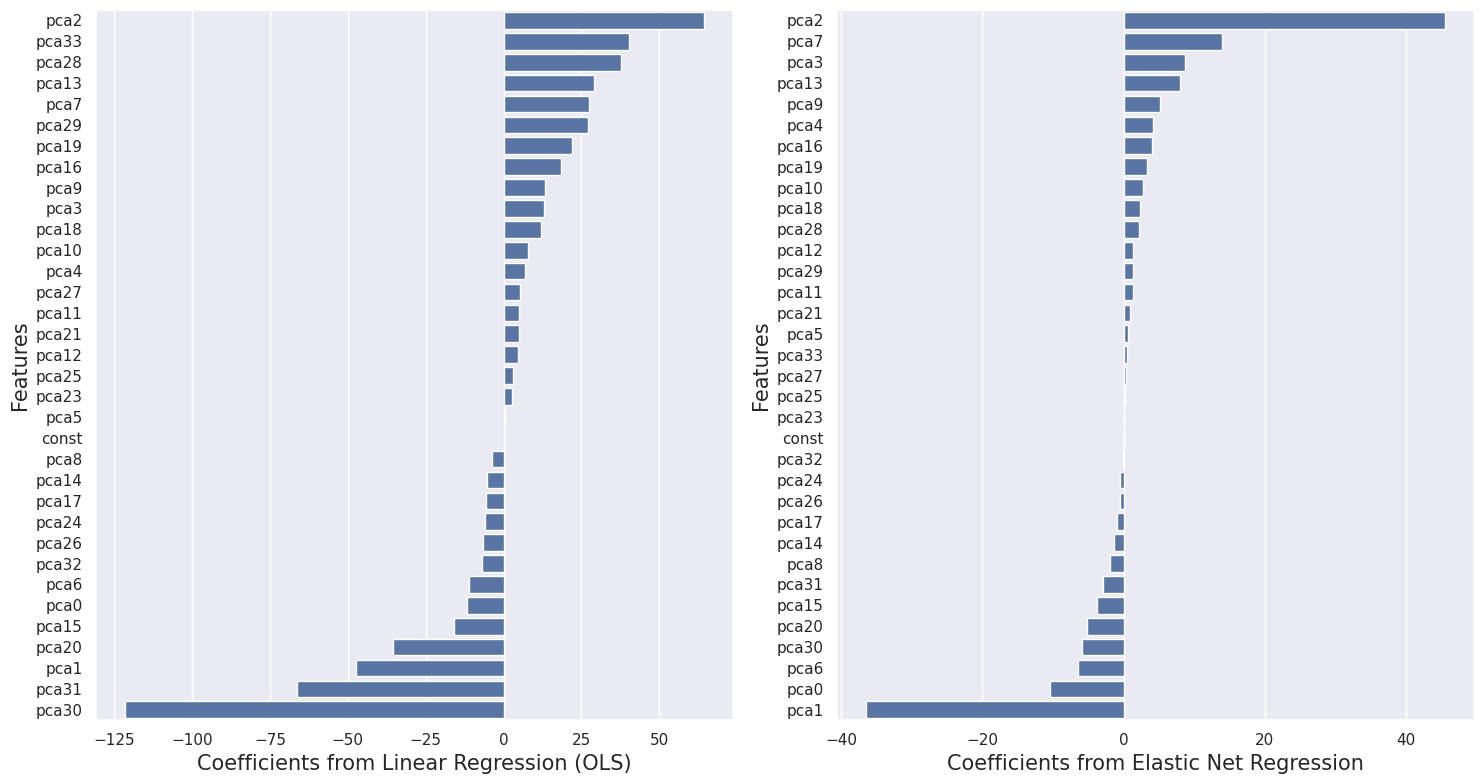

In [182]:
plt.subplot(1,2,1)
plot_coefficients(MLR_model, 'Linear Regression (OLS)')

plt.subplot(1,2,2)
plot_coefficients(enet, 'Elastic Net Regression')

plt.tight_layout()

The second subplot (on the right) shows that the elastic-net regression has reduced the coefficients of some variables to zero.

## 9.5.4 Grid Search CV<a id="gri_sea"></a>

In [183]:
tuned_paramaters = [{'alpha':[1e-15, 1e-10, 1e-8, 1e-4,1e-3, 1e-2, 0.1, 1, 5, 10, 20, 40, 60, 80, 100]}]

ridge = Ridge()
ridge_grid = GridSearchCV(estimator = ridge,
                          param_grid = tuned_paramaters,
                          cv = 10)

ridge_grid.fit(X_train, y_train)

print('Best parameters for Ridge Regression: ', ridge_grid.best_params_, '\n')
print('RMSE on test set:', get_test_rmse(ridge_grid))

Best parameters for Ridge Regression:  {'alpha': 0.01} 

RMSE on test set: 4.1441


In [184]:
update_score_card(algorithm_name = 'Ridge Regression (using GridSearchCV)',
                  model = ridge_grid,
                  alpha = ridge_grid.best_params_.get('alpha'))

In [185]:
tuned_paramaters = [{'alpha':[1e-15, 1e-10, 1e-8, 0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 20]}]

lasso = Lasso()
lasso_grid = GridSearchCV(estimator = lasso,
                          param_grid = tuned_paramaters,
                          cv = 10)

lasso_grid.fit(X_train, y_train)

print('Best parameters for Lasso Regression: ', lasso_grid.best_params_, '\n')
print('RMSE on test set:', get_test_rmse(lasso_grid))

Best parameters for Lasso Regression:  {'alpha': 0.0001} 

RMSE on test set: 4.1437


In [186]:
update_score_card(algorithm_name = 'Lasso Regression (using GridSearchCV)',
                  model = lasso_grid,
                  alpha = lasso_grid.best_params_.get('alpha'))

In [187]:
tuned_paramaters = [{'alpha':[0.0001, 0.001, 0.01, 0.1, 1, 5, 10, 20, 40, 60],
                      'l1_ratio':[0.0001, 0.0002, 0.001, 0.01, 0.1, 0.2, 0.4, 0.55]}]

enet = ElasticNet()
enet_grid = GridSearchCV(estimator = enet,
                          param_grid = tuned_paramaters,
                          cv = 10)

enet_grid.fit(X_train, y_train)

print('Best parameters for Elastic Net Regression: ', enet_grid.best_params_, '\n')
print('RMSE on test set:', get_test_rmse(enet_grid))

Best parameters for Elastic Net Regression:  {'alpha': 0.0001, 'l1_ratio': 0.55} 

RMSE on test set: 4.155


In [188]:
update_score_card(algorithm_name = 'Elastic Net Regression (using GridSearchCV)',
                  model = enet_grid,
                  alpha = enet_grid.best_params_.get('alpha'),
                  l1_ratio = enet_grid.best_params_.get('l1_ratio'))

# 10. Displaying score summary<a id="dis_sco_sum"></a>

In [189]:
score_card = score_card.sort_values('Test_RMSE').reset_index(drop = True)
score_card.style.highlight_min(color = 'lightblue', subset = 'Test_RMSE')

,Model_Name,Alpha (Wherever Required),l1-ratio,R-Squared,Adj. R-Squared,Train_RMSE,Test_RMSE,Test_MAPE
0,Lasso Regression (using GridSearchCV),0.000100,-,0.991460,0.991381,4.348100,4.143700,1.280294
1,Ridge Regression (using GridSearchCV),0.010000,-,0.991460,0.991381,4.348100,4.144100,1.280284
2,Ridge Regression (with alpha = 0.1),0.100000,-,0.991458,0.991379,4.348500,4.150000,1.280488
3,Elastic Net Regression (using GridSearchCV),0.000100,0.550000,0.991455,0.991376,4.349400,4.155000,1.280720
4,Ridge Regression (with alpha = 0.5),0.500000,-,0.991418,0.991339,4.358700,4.184600,1.283219
5,Linear Regression (using SGD),-,-,0.991275,0.991194,4.395000,4.226700,1.296287
6,Ridge Regression (with alpha = 1),1,-,0.991303,0.991223,4.387800,4.243600,1.291366
7,Ridge Regression (with alpha = 2),2,-,0.990903,0.990819,4.487600,4.400100,1.320496
8,Lasso Regression,0.05,-,0.988811,0.988707,4.977000,4.953400,1.484178
9,Elastic Net Regression,0.1,0.55,0.908621,0.907772,14.223200,14.925700,4.668022


# 11. Conclusion<a id="conclu"></a>

* Lasso Regression using Grid search CV has been the most effective in reducing RMSE .
* The exact combination of features responsible for high CO2 emissions cannot be predicted  Since all the features are highly correlated
* We can hereby conclude that we have successfully built a model that can predict amount of CO2 Emissions across different vehicle types at a high accuracy rate.